#  The Winton Stock Market Challenge 📈

This notebook contains data analysis and modeling of a stock data. Each row of the data contains data points of a 5-day windows, 25 masked features, and weights for intraday and interday predictions.

The given weights are used in the metrics calculation. The formula for the metric is as follows.

$$
WMAE = \frac{1}{n} \sum_{i=1}^{n} w_i \cdot |y_i - \hat{y_i}|
$$

# Data Dictionary 📑

- **Feature_1 to Feature_25:** different features relevant to prediction
- **Ret_MinusTwo:**  this is the return from the close of trading on day D-2 to the close of trading on day D-1 (i.e. 1 day)
- **Ret_MinusOne:** this is the return from the close of trading on day D-1 to the point at which the intraday returns start on day D (approximately 1/2 day)
- **Ret_2 to Ret_120:** these are returns over approximately one minute on day D. Ret_2 is the return between t=1 and t=2. 
- **Ret_121 to Ret_180:** intraday returns over approximately one minute on day D. **These are the target variables you need to predict as {id}_{1-60}.** 
- **Ret_PlusOne:** this is the return from the time Ret_180 is measured on day D to the close of trading on day D+1. (approximately 1 day). **This is a target variable you need to predict as {id}\_61.** 
- **Ret_PlusTwo:** this is the return from the close of trading on day D+1 to the close of trading on day D+2 (i.e. 1 day) **This is a target variable you need to predict as {id}_62.**
- **Weight_Intraday:** weight used to evaluate intraday return predictions Ret 121 to 180
- **Weight_Daily:** weight used to evaluate daily return predictions (Ret_PlusOne and Ret_PlusTwo).

![img](https://storage.googleapis.com/kaggle-competitions/kaggle/4504/media/Presentation1%20(1).jpg)

# Initial Ideas 🕯️

- The forecasts can be categorized into 2 types, intraday and interday.
- The intraday returns are calculated from the difference of 180 time steps from the days
    - ARIMA might not be suitable since each row are disconnected time series and the periodicity of intraday might not be apparent
    - Tabular regressors might be more suitable but we're going to have to handle moving time windows. So, we have a couple approach to try
        - Recursive forecast: Using the forecasts as the next feature
        - Direct forecast: Make multiple forecasters for each of the time step
- The interday returns might be more tricky since there are only a few time steps before our forecasting targets. They might depend on
    - Daily returns of the previous days
    - Daily returns of the previous days with the characteristics of the latest intraday returns
- If there are missing values,
    - Using LOCF for imputation would mean that the stock price keeps it's direction after the latest observation
    - Using 0 would mean that the stock price remains the same after the latest observation
    - Using mean return would imply that the stock would return to it's average direction

# Libraries 📚

In [1]:
!pip install sktime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 14.9 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt # visualization
import missingno as msno # missing data visualization
import numpy as np # array manipulation
import pandas as pd # dataframe manipulation
import scipy # statistical tests
import seaborn as sns # visualization
from zipfile import ZipFile # reading zip file

# statsmodels for doing stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# sktime for time series imputation
from sktime.transformations.series.impute import Imputer

# sklearn for modeling
from sklearn.base import RegressorMixin
from sklearn.linear_model import LinearRegression

# xgboost for boosting
from xgboost import XGBRegressor

# Global Variables 🌏

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Raw Data 🥩

In [4]:
zip_file = ZipFile('../input/the-winton-stock-market-challenge/train.csv.zip')
raw_df = pd.read_csv(zip_file.open('train.csv'))

In [5]:
def display_all_columns(df: pd.DataFrame):
    with pd.option_context('display.max_columns', None): 
        display(df)

In [6]:
display_all_columns(raw_df.head())

,Id,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Ret_MinusTwo,Ret_MinusOne,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,Ret_10,Ret_11,Ret_12,Ret_13,Ret_14,Ret_15,Ret_16,Ret_17,Ret_18,Ret_19,Ret_20,Ret_21,Ret_22,Ret_23,Ret_24,Ret_25,Ret_26,Ret_27,Ret_28,Ret_29,Ret_30,Ret_31,Ret_32,Ret_33,Ret_34,Ret_35,Ret_36,Ret_37,Ret_38,Ret_39,Ret_40,Ret_41,Ret_42,Ret_43,Ret_44,Ret_45,Ret_46,Ret_47,Ret_48,Ret_49,Ret_50,Ret_51,Ret_52,Ret_53,Ret_54,Ret_55,Ret_56,Ret_57,Ret_58,Ret_59,Ret_60,Ret_61,Ret_62,Ret_63,Ret_64,Ret_65,Ret_66,Ret_67,Ret_68,Ret_69,Ret_70,Ret_71,Ret_72,Ret_73,Ret_74,Ret_75,Ret_76,Ret_77,Ret_78,Ret_79,Ret_80,Ret_81,Ret_82,Ret_83,Ret_84,Ret_85,Ret_86,Ret_87,Ret_88,Ret_89,Ret_90,Ret_91,Ret_92,Ret_93,Ret_94,Ret_95,Ret_96,Ret_97,Ret_98,Ret_99,Ret_100,Ret_101,Ret_102,Ret_103,Ret_104,Ret_105,Ret_106,Ret_107,Ret_108,Ret_109,Ret_110,Ret_111,Ret_112,Ret_113,Ret_114,Ret_115,Ret_116,Ret_117,Ret_118,Ret_119,Ret_120,Ret_121,Ret_122,Ret_123,Ret_124,Ret_125,Ret_126,Ret_127,Ret_128,Ret_129,Ret_130,Ret_131,Ret_132,Ret_133,Ret_134,Ret_135,Ret_136,Ret_137,Ret_138,Ret_139,Ret_140,Ret_141,Ret_142,Ret_143,Ret_144,Ret_145,Ret_146,Ret_147,Ret_148,Ret_149,Ret_150,Ret_151,Ret_152,Ret_153,Ret_154,Ret_155,Ret_156,Ret_157,Ret_158,Ret_159,Ret_160,Ret_161,Ret_162,Ret_163,Ret_164,Ret_165,Ret_166,Ret_167,Ret_168,Ret_169,Ret_170,Ret_171,Ret_172,Ret_173,Ret_174,Ret_175,Ret_176,Ret_177,Ret_178,Ret_179,Ret_180,Ret_PlusOne,Ret_PlusTwo,Weight_Intraday,Weight_Daily
0,1,NaN,NaN,NaN,NaN,8.0,NaN,75751,0.2254,11.0,NaN,NaN,0.49,5.0,1.842984,27.053679,1.0,NaN,NaN,-0.925463,2.0,NaN,-0.489492,NaN,NaN,NaN,0.055275,-0.010770,0.000003,-0.000734,-0.000738,-0.000007,0.000423,0.000438,-0.000076,0.000645,-0.000006,0.000006,NaN,-0.000156,NaN,NaN,-0.000430,-1.964625e-05,0.000002,-0.000031,NaN,NaN,-7.539950e-06,NaN,0.000416,-0.000164,-0.000009,-0.000438,NaN,0.000010,-7.176461e-04,-0.000162,NaN,NaN,NaN,-0.000582,0.001003,-0.000010,0.000134,0.000014,-0.000142,-0.001003,-0.000007,-0.000005,-1.277039e-05,NaN,0.000706,-0.000734,-7.311366e-04,-0.001996,-0.000153,0.000133,NaN,NaN,-0.000007,0.000713,0.000009,NaN,-0.000432,-0.001152,-0.000723,9.982299e-07,-0.003579,0.000435,-0.000012,-0.000132,0.000004,0.000418,-0.000011,NaN,-0.002724,-0.002996,0.000129,0.000012,-0.000002,-1.369941e-04,-0.003537,-0.000142,0.000135,0.000020,-1.318606e-04,0.000449,-0.000008,0.000006,0.000282,-1.390130e-04,-1.284489e-04,0.000005,-0.000005,-1.693501e-03,-0.002141,0.000003,-0.000274,-0.000015,0.001279,0.000282,-0.000003,-0.000156,0.000024,-0.000560,-0.000580,0.000138,-0.002277,0.000125,0.000406,-0.000427,-0.000013,-0.000843,1.666111e-04,0.000569,0.000695,NaN,0.000700,-0.000843,0.000268,-0.000415,-0.001133,0.000004,-0.000137,-0.000009,1.340780e-04,-0.000137,-0.000565,-0.000704,-0.005605,0.000826,0.001966,0.002676,0.000422,-0.000428,-0.000539,-0.002113,-0.001400,-0.000017,-0.002801,-0.000003,0.002099,0.000698,0.000547,-0.001976,0.000012,0.001112,0.000284,0.000003,-0.001976,-0.000842,-0.001390,0.000148,2.846942e-04,0.001254,-0.000130,0.000126,0.000978,0.000151,0.002642,-0.000017,0.000140,0.000015,-0.000011,0.001683,-0.000286,0.000010,0.000152,0.000579,-1.501973e-04,0.000822,0.001392,0.000292,0.000002,0.001133,-0.000134,0.001539,-0.000142,0.000861,0.000544,-0.002688,0.002246,-0.000838,-6.953224e-04,0.000003,-0.001974,-0.019512,0.028846,1.251508e+06,1.564385e+06
1,2,NaN,NaN,NaN,NaN,3.0,0.388896,17369,0.0166,13.0,NaN,-0.409923,0.71,9.0,1.577586,9.546915,1.0,-0.949891,0.917958,-0.897067,9.0,0.886205,-0.151805,1.239856,0.953424,-0.709462,0.009748,0.002987,-0.000487,0.000475,0.000002,-0.000002,-0.000523,-0.000255,-0.000008,0.000048,-0.000312,-0.000742,-0.000009,-0.000248,0.000487,0.000256,-0.000508,2.495416e-04,0.000015,0.000008,-0.000251,-0.000519,-5.029784e-04,0.000240,0.000248,0.000495,-0.000243,-0.

Just from displaying the first few rows we can see that there can be missing values in both the feature columns and the return data.

In [7]:
raw_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 211 columns):
 #    Column           Dtype  
---   ------           -----  
 0    Id               int64  
 1    Feature_1        float64
 2    Feature_2        float64
 3    Feature_3        float64
 4    Feature_4        float64
 5    Feature_5        float64
 6    Feature_6        float64
 7    Feature_7        int64  
 8    Feature_8        float64
 9    Feature_9        float64
 10   Feature_10       float64
 11   Feature_11       float64
 12   Feature_12       float64
 13   Feature_13       float64
 14   Feature_14       float64
 15   Feature_15       float64
 16   Feature_16       float64
 17   Feature_17       float64
 18   Feature_18       float64
 19   Feature_19       float64
 20   Feature_20       float64
 21   Feature_21       float64
 22   Feature_22       float64
 23   Feature_23       float64
 24   Feature_24       float64
 25   Feature_25       float64
 26   Ret_MinusTwo    

Using .info() method shows that besides Id and Feature_7 column, the data types of every columns are in float64. No type casting is needed. We can proceed to the next step, creating the test set with random sampling for **20%** of the data. But first, let's make sure every rows in raw data have weights before sampling since we can't compute metrics without them.

In [8]:
raw_df["Weight_Intraday"].isna().sum()

0

In [9]:
raw_df["Weight_Daily"].isna().sum()

0

No missing weights. We can proceed with the sampling. Since Ret_PlusOne and Ret_PlusTwo are not in the moving time window format (and also not given), we don't have to worry about time dependencies between rows.

In [10]:
test_df = raw_df.sample(frac=0.2, random_state=RANDOM_STATE).sort_index()
test_df.head()

,Id,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Ret_175,Ret_176,Ret_177,Ret_178,Ret_179,Ret_180,Ret_PlusOne,Ret_PlusTwo,Weight_Intraday,Weight_Daily
1,2,NaN,NaN,NaN,NaN,3.0,0.388896,17369,0.0166,13.0,...,-0.000129,0.000123,0.000248,3.315418e-07,0.000003,0.000027,-0.002939,-0.010253,1.733950e+06,2.167438e+06
4,5,6.0,-1.736489,2.765531,1.245280,7.0,4.866985,22423,0.2138,13.0,...,-0.001235,0.000027,0.002449,8.619882e-06,0.001209,-0.000004,0.036104,-0.026552,1.267270e+06,1.584088e+06
7,8,NaN,2.582955,0.157344,0.617261,8.0,-0.177333,92214,0.2119,8.0,...,-0.000247,-0.000250,0.000010,1.620296e-05,0.000245,0.000006,0.020268,-0.059093,1.349917e+06,1.687396e+06
13,14,NaN,0.480362,0.915407,1.381156,7.0,0.223401,35023,0.2138,10.0,...,0.000295,-0.001858,0.001133,-1.288622e-03,-0.000433,-0.000574,-0.010936,-0.019700,1.460081e+06,1.825101e+06
23,24,NaN,-1.833909,0.807421,0.396305,7.0,0.225614,57773,0.2986,7.0,...,0.000663,-0.003362,-0.002676,2.674716e-03,0.002692,-0.003376,0.076162,0.013566,1.208516e+06,1.510645e+06


In [11]:
test_df.tail()

,Id,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Ret_175,Ret_176,Ret_177,Ret_178,Ret_179,Ret_180,Ret_PlusOne,Ret_PlusTwo,Weight_Intraday,Weight_Daily
39973,39974,NaN,NaN,0.247709,0.708384,1.0,0.516685,39562,0.3318,12.0,...,-0.000635,0.000625,0.000010,0.000950,1.271857e-05,-2.605154e-07,0.016990,0.000616,1.518609e+06,1.898261e+06
39974,39975,NaN,-0.795393,0.812479,1.182253,2.0,0.435337,34124,0.3650,10.0,...,-0.001339,0.000944,0.000387,0.000577,-2.094398e-06,1.228960e-05,0.008246,-0.025444,1.467096e+06,1.833870e+06
39977,39978,NaN,1.584213,1.485364,NaN,5.0,0.181444,48365,0.2119,11.0,...,0.000376,-0.000660,0.000392,-0.000129,-3.927012e-04,3.845017e-04,0.001195,-0.001933,1.813249e+06,2.266561e+06
39986,39987,NaN,-1.304033,1.063957,0.448434,9.0,0.276835,34425,0.2208,11.0,...,0.000003,-0.000210,0.000007,0.000195,2.002236e-04,-1.097263e-04,-0.030169,0.001835,1.388133e+06,1.735166e+06
39992,39993,NaN,-0.787167,1.189032,0.168022,10.0,0.187430,82639,0.0142,8.0,...,0.000223,-0.000005,0.000857,-0.000183,-9.980441e-07,-5.580793e-06,0.002926,0.005249,1.411322e+06,1.764153e+06


In [12]:
test_df.shape

(8000, 211)

Everything about the test set seems to be in order. Next, the data points that are in the test set must be removed from the raw data to create training set.

In [13]:
train_df = raw_df[~raw_df["Id"].isin(test_df["Id"])]
train_df.head()

,Id,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Ret_175,Ret_176,Ret_177,Ret_178,Ret_179,Ret_180,Ret_PlusOne,Ret_PlusTwo,Weight_Intraday,Weight_Daily
0,1,NaN,NaN,NaN,NaN,8.0,NaN,75751,0.2254,11.0,...,-0.002688,0.002246,-0.000838,-0.000695,0.000003,-0.001974,-0.019512,0.028846,1.251508e+06,1.564385e+06
2,3,NaN,-0.696727,0.739591,-0.167928,9.0,0.471947,8277,0.3650,9.0,...,-0.000524,-0.000394,0.000116,0.000532,0.000274,0.000784,-0.024791,0.015711,1.529197e+06,1.911497e+06
3,4,NaN,-0.694350,1.568248,0.479073,5.0,0.120653,22508,0.2654,13.0,...,0.000346,-0.000090,0.000288,-0.000128,0.000074,0.000341,-0.005680,-0.002190,1.711569e+06,2.139462e+06
5,6,NaN,NaN,-0.680515,NaN,1.0,0.227034,24099,0.2064,8.0,...,0.000242,0.001412,0.001880,-0.000946,0.000471,0.001193,0.031098,-0.006551,1.431110e+06,1.788888e+06
6,7,NaN,-0.230636,-0.227021,-0.084126,7.0,-0.095007,39351,0.3650,13.0,...,0.000326,-0.000408,0.000086,-0.000012,-0.000006,0.000640,-0.011105,-0.030745,1.719166e+06,2.148958e+06


In [14]:
train_df.tail()

,Id,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Ret_175,Ret_176,Ret_177,Ret_178,Ret_179,Ret_180,Ret_PlusOne,Ret_PlusTwo,Weight_Intraday,Weight_Daily
39995,39996,NaN,NaN,0.822371,NaN,1.0,2.182050,23729,0.2208,12.0,...,0.000623,0.000504,1.490012e-03,0.000623,-0.000516,-0.000876,-0.024270,0.010143,1.413891e+06,1.767363e+06
39996,39997,NaN,0.747556,-0.489418,-0.267193,10.0,-0.454329,56222,0.2323,8.0,...,0.000649,0.001290,-6.031396e-07,-0.001278,-0.000658,0.000628,0.017855,-0.000094,1.468998e+06,1.836248e+06
39997,39998,NaN,NaN,-0.914701,-1.013004,2.0,-0.701013,7024,0.3418,10.0,...,0.001375,0.000005,7.888841e-04,0.000211,-0.000573,-0.001568,0.011602,-0.006539,1.812824e+06,2.266030e+06
39998,39999,NaN,-0.021457,1.021284,NaN,3.0,1.092849,27376,0.2119,13.0,...,0.000273,0.000017,2.471045e-04,-0.000138,0.000015,-0.000123,-0.018877,-0.011572,1.507918e+06,1.884897e+06
39999,40000,NaN,1.093868,-0.677391,-0.604479,7.0,NaN,4141,0.2254,NaN,...,-0.000914,-0.002752,1.350722e-03,0.000903,0.003667,0.002761,0.024405,-0.024345,1.535389e+06,1.919237e+06


In [15]:
train_df.shape

(32000, 211)

# Exploratory Data Analysis 🔍

For easier slicing, let's make lists of columns by types.

In [16]:
feature_cols = [f"Feature_{i}" for i in range(1, 26)]
intra_ret_feat_cols = [f"Ret_{i}" for i in range(2, 121)]
intra_ret_target_cols = [f"Ret_{i}" for i in range(121, 181)]
intra_ret_cols = intra_ret_feat_cols + intra_ret_target_cols
inter_ret_feat_cols = ["Ret_MinusTwo", "Ret_MinusOne"]
inter_ret_target_cols = ["Ret_PlusOne", "Ret_PlusTwo"]
inter_ret_cols = inter_ret_feat_cols + inter_ret_target_cols

## Missing Data

In [17]:
def plot_missing(df: pd.DataFrame, name: str):
    nrows, ncols = df.shape
    notna_df = df.notna().sum().to_frame().T
    percent_notna_df = (notna_df / nrows) * 100
    fig, ax = plt.subplots(1, 1, figsize=(7, ncols * 0.25))
    sns.barplot(percent_notna_df, orient="h", ax=ax)
    ax.set_xlim(0, 110)
    ax.bar_label(ax.containers[0], fmt="%.2f");
    ax.set_title(f"Percentage of Non Null Values in {name}")
    ax.set_xlabel("%")
    ax.set_ylabel("Column")

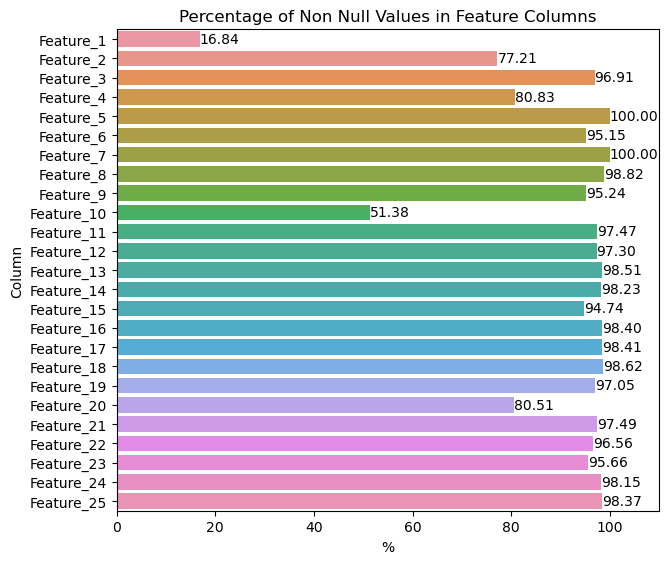

In [18]:
plot_missing(train_df.loc[:, feature_cols], "Feature Columns")

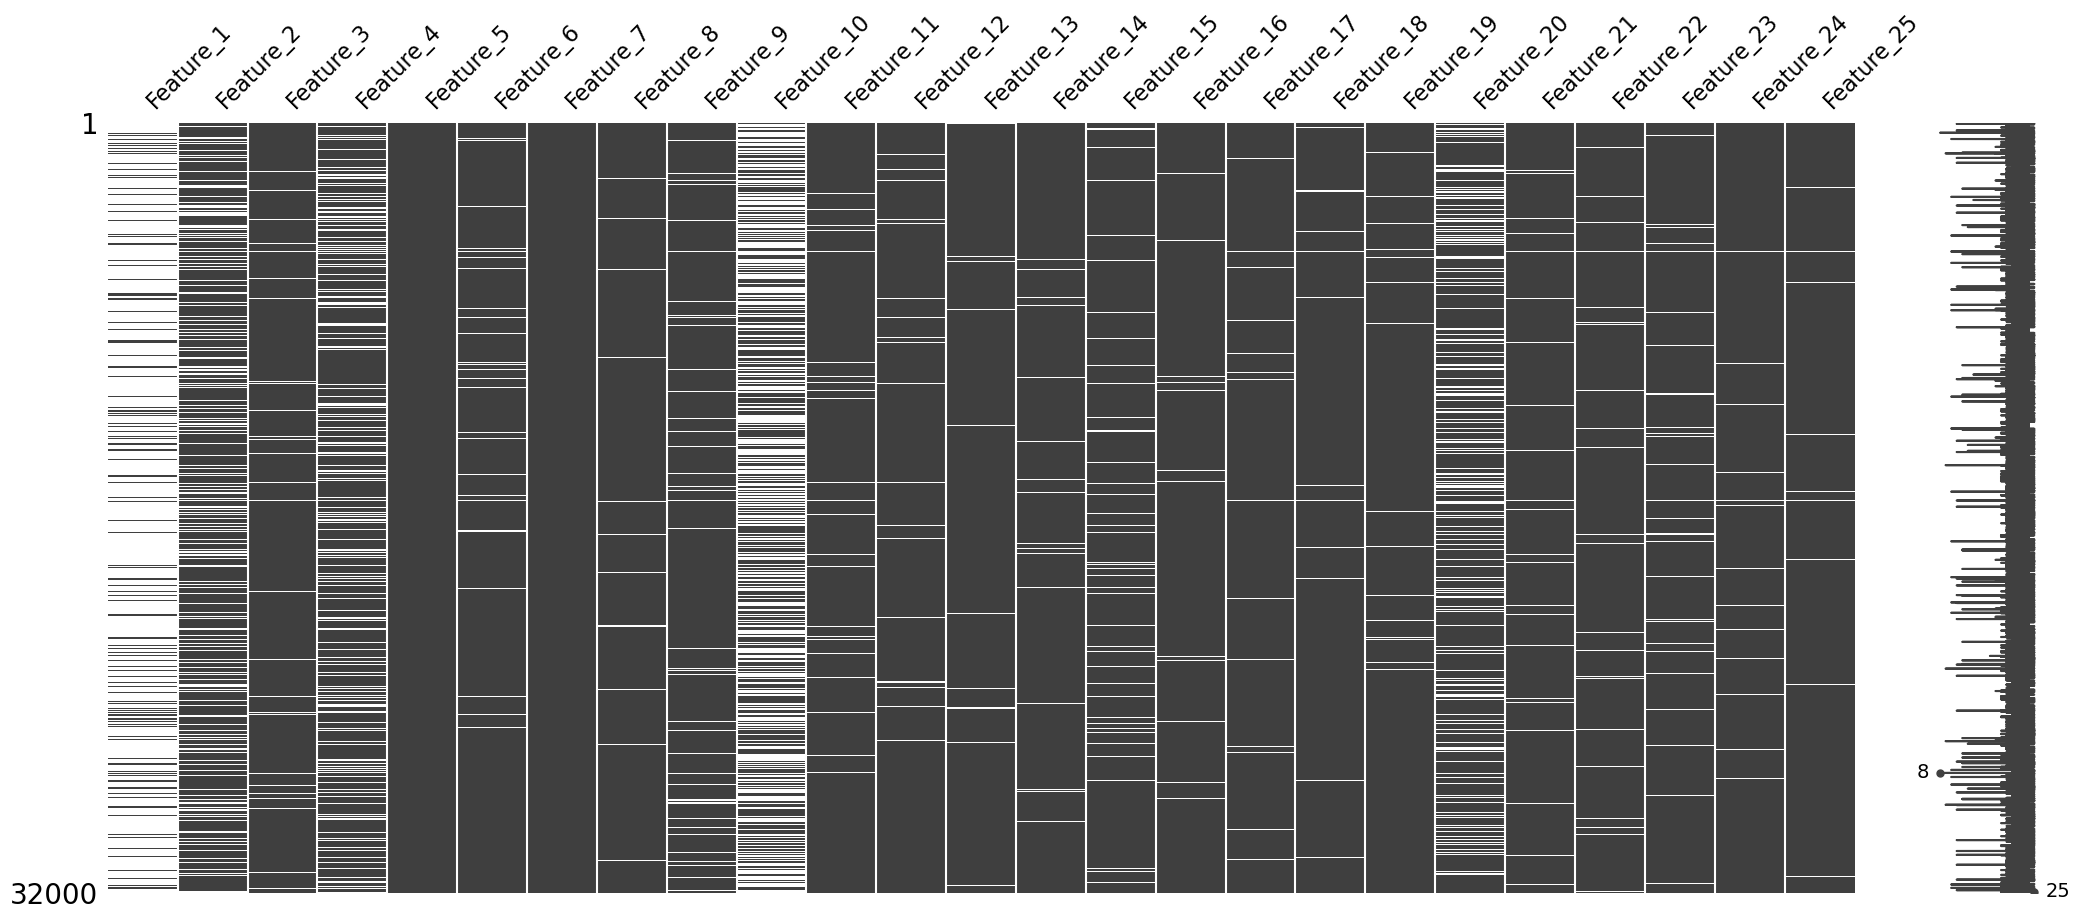

In [19]:
msno.matrix(train_df.loc[:, feature_cols]);

Most Feature columns have high availability of the data with less than 10% missing data. Anyhow, there are some columns that have around 80% of the data available which are **Feature_2, Feature_4, and Feature_20.** Also, there are some that have low data availability, namely, **Feature_10** has about half while **Feature_1** has only 16.84%!

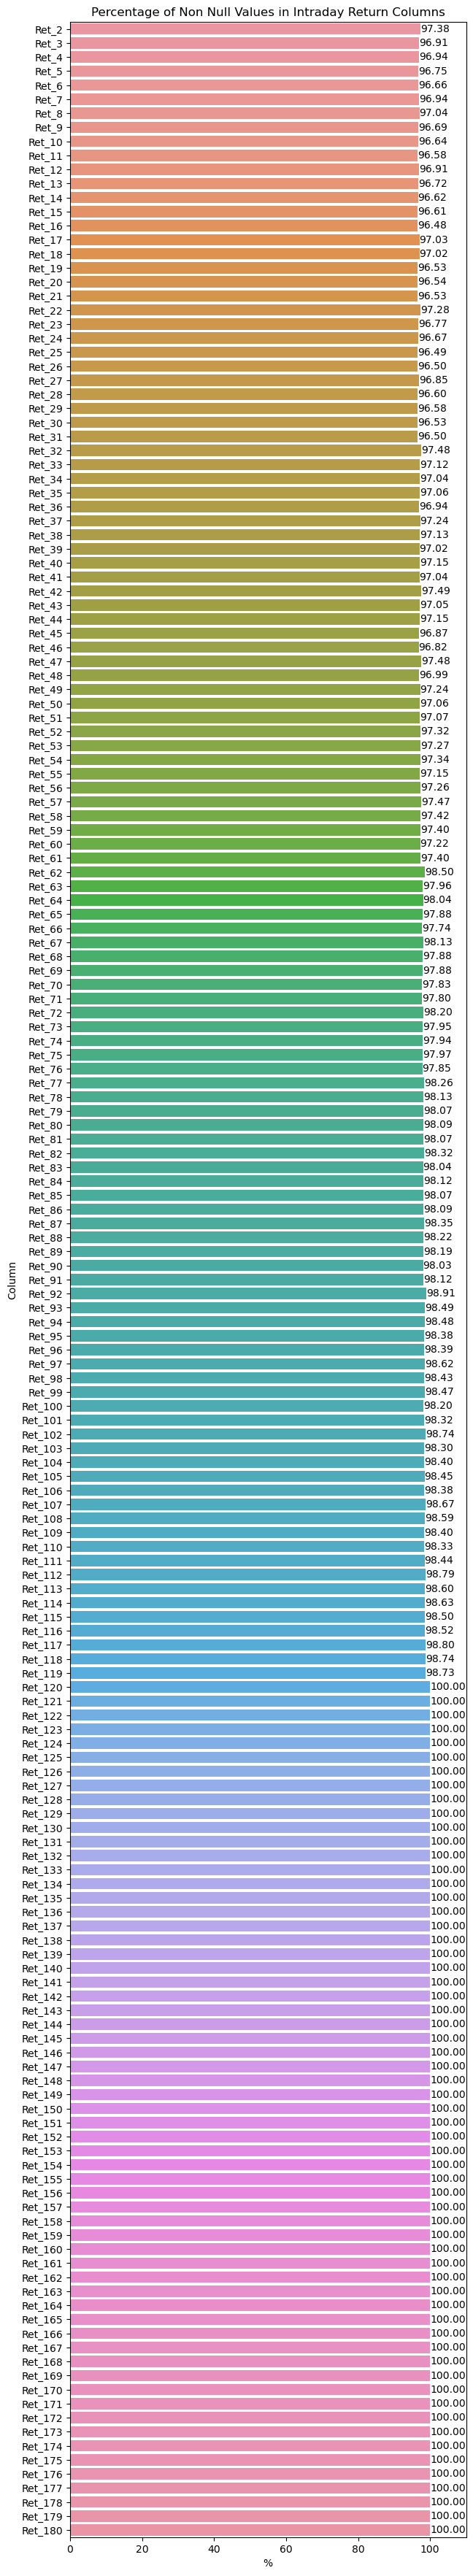

In [20]:
plot_missing(train_df.loc[:, intra_ret_cols], "Intraday Return Columns")

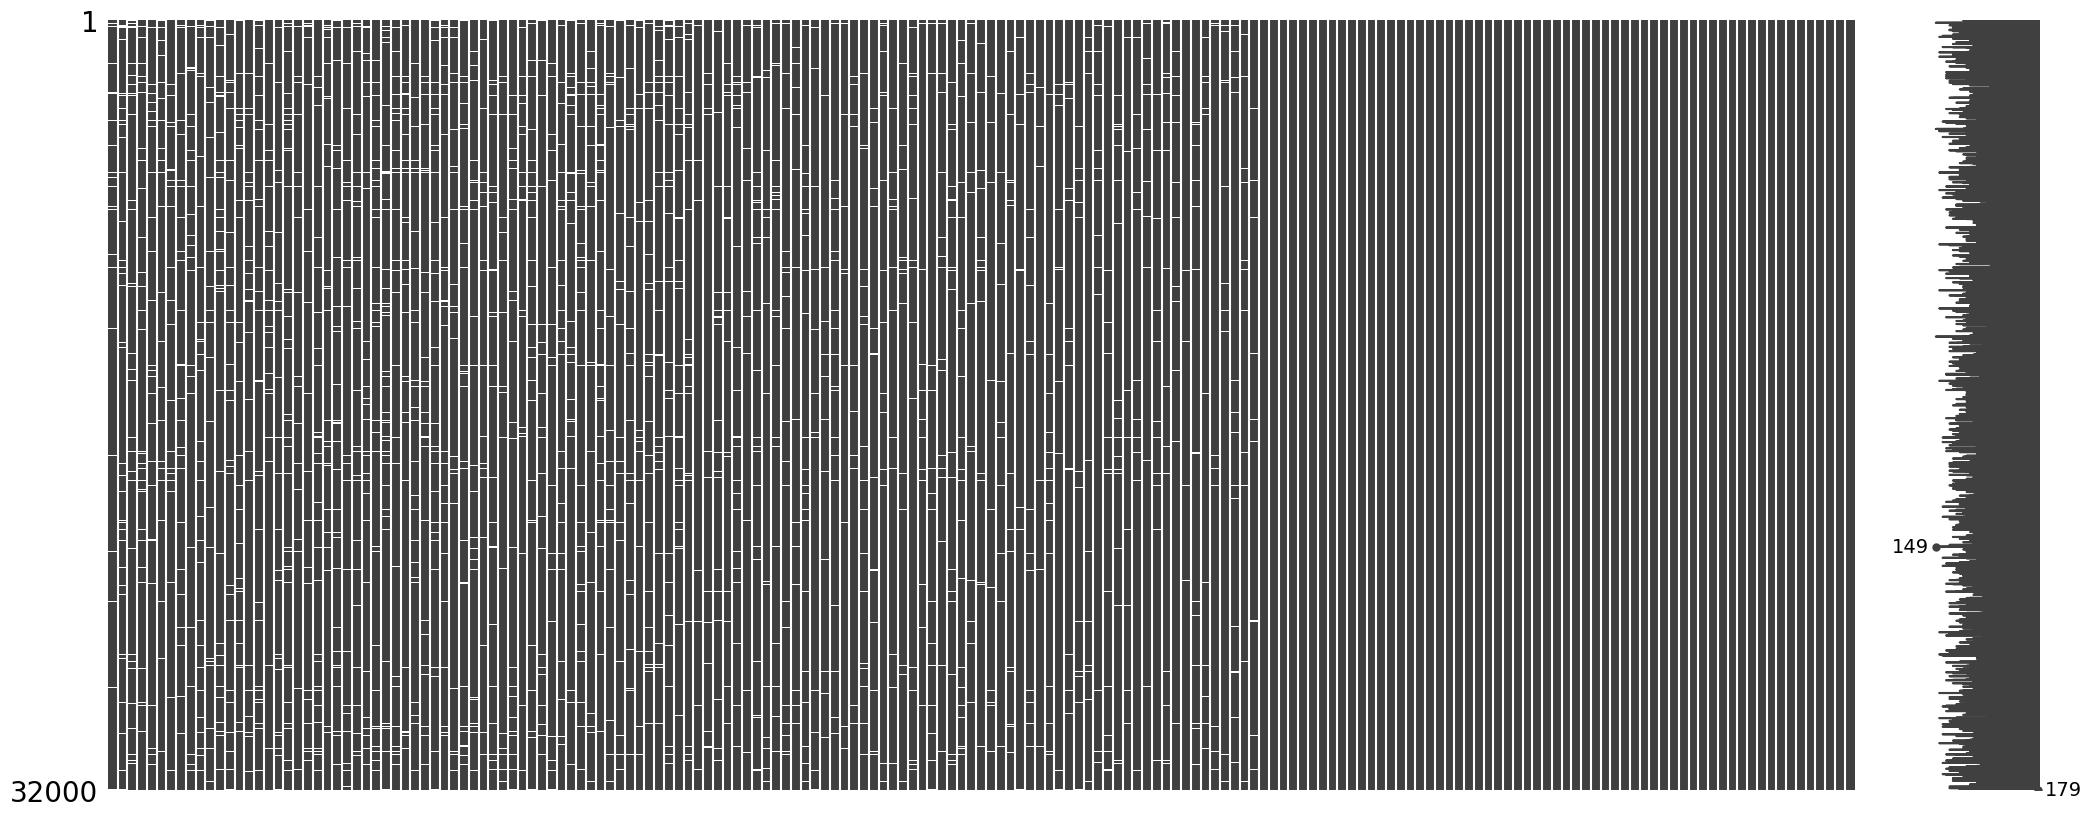

In [21]:
msno.matrix(train_df.loc[:, intra_ret_cols]);

Intraday return data is close to being full. With every columns having over 96% of the data to be non-missing, and since imputation of consecutive time series data points can be done easily with LOCF and LOCB (although might not be fit for this case) or imputing the mean, this means we don't have to worry about missing data of intraday return (for now). Also, the columns of the forecasting targets are all complete.

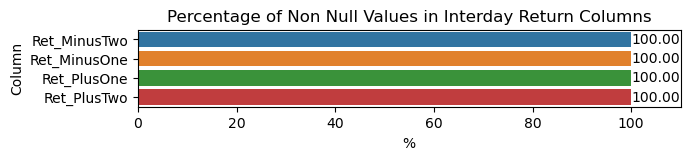

In [22]:
plot_missing(train_df.loc[:, inter_ret_cols], "Interday Return Columns")

No missing data for interday returns. We can proceed with these columns as is.

## Inspect Columns with High Missing Data Percentage

Although it's tempting to just drop the columns with high amount of missing data, we should try to find patterns or relationship between such columns and our target to have some evidences for dropping them. We can start by answering some simple questions.

**Does the observations that are missing Feature_1 have different intraday returns?**

We can try to answer this by compare the histogram of the returns between the two groups. First, let's check the number of data points (exclusing the NaNs).

In [23]:
train_df[~train_df["Feature_1"].isna()].stack()

12     Id                 1.300000e+01
       Feature_1          6.000000e+00
       Feature_2          4.123636e-02
       Feature_3         -3.860444e-01
       Feature_4          2.551674e-01
                              ...     
39984  Ret_180           -2.354591e-04
       Ret_PlusOne       -1.186162e-02
       Ret_PlusTwo       -9.329307e-03
       Weight_Intraday    1.381946e+06
       Weight_Daily       1.727433e+06
Length: 1119141, dtype: float64

In [24]:
train_df[train_df["Feature_1"].isna()].stack()

0      Id                 1.000000e+00
       Feature_5          8.000000e+00
       Feature_7          7.575100e+04
       Feature_8          2.254000e-01
       Feature_9          1.100000e+01
                              ...     
39999  Ret_180            2.760911e-03
       Ret_PlusOne        2.440521e-02
       Ret_PlusTwo       -2.434548e-02
       Weight_Intraday    1.535389e+06
       Weight_Daily       1.919237e+06
Length: 5465263, dtype: float64

The number of available return data that has Feature_1 is almost 1:5 to the data that doesn't have Feature_1.

Next, we perform a statistical test to determine whether there is statistical evidence that the associated population means are significantly different.

In [25]:
with_Feature_1_array = train_df[~train_df["Feature_1"].isna()].stack().values
without_Feature_1_array = train_df[train_df["Feature_1"].isna()].stack().values

In [26]:
ttest_result_Feature_1 = scipy.stats.ttest_ind(with_Feature_1_array, without_Feature_1_array)
ttest_result_Feature_1

Ttest_indResult(statistic=-1.8071903767125863, pvalue=0.07073264650083641)

Since the p-value of the t-test is more that 5%, we failed to reject the null hypothesis that the population means are equal. We can also compare kde plots between the two. Since there are more than a million elements in our array, we can sample the array before plotting to reduce computational time.

In [27]:
with_Feature_1_sample_array = np.random.choice(with_Feature_1_array, size=10_000)
without_Feature_1_sample_array = np.random.choice(without_Feature_1_array, size=10_000)

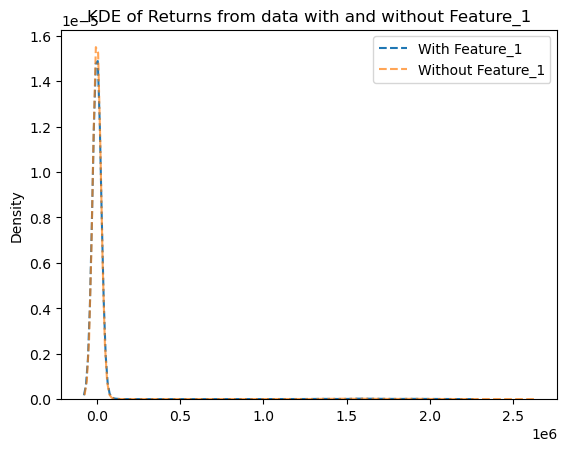

In [28]:
sns.kdeplot(data=with_Feature_1_sample_array, linestyle="--", label="With Feature_1")
ax = sns.kdeplot(data=without_Feature_1_sample_array, alpha=0.7, linestyle="--", label="Without Feature_1")
ax.set_title("KDE of Returns from data with and without Feature_1")
ax.legend();

**Does the same go for Feature_10?**

In [29]:
with_Feature_10_array = train_df[~train_df["Feature_10"].isna()].stack().values
without_Feature_10_array = train_df[train_df["Feature_10"].isna()].stack().values

In [30]:
ttest_result_Feature_10 = scipy.stats.ttest_ind(with_Feature_10_array, without_Feature_10_array)
ttest_result_Feature_10

Ttest_indResult(statistic=-6.005924067746009, pvalue=1.9025513144500258e-09)

In [31]:
with_Feature_10_sample_array = np.random.choice(with_Feature_10_array, size=10_000)
without_Feature_10_sample_array = np.random.choice(without_Feature_10_array, size=10_000)

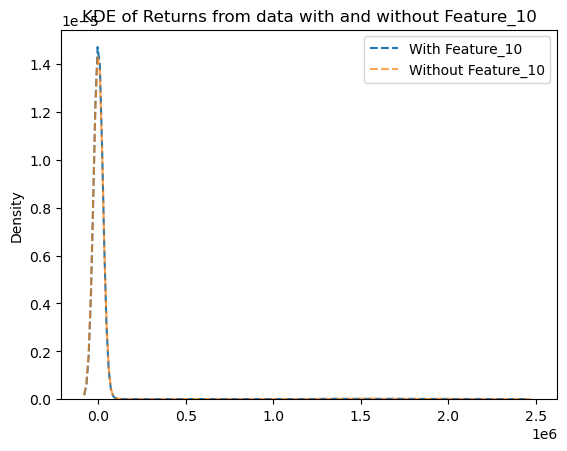

In [32]:
sns.kdeplot(data=with_Feature_10_sample_array, linestyle="--", label="With Feature_10")
ax = sns.kdeplot(data=without_Feature_10_sample_array, alpha=0.7, linestyle="--", label="Without Feature_10")
ax.set_title("KDE of Returns from data with and without Feature_10")
ax.legend();

The kde shows that the distributions of the 2 groups are similar. But. This time the t-test result shows that the p-value is now well less than 5%. This means that we have evidence **against** the null hypothesis of equal means.

However, If we don't drop Feature_10 that means we are going to have about half of the training data with missing values. We can drop it for now.

## Inspect Missing Data in Intraday Returns  

In [33]:
intra_ret_train_df = train_df.loc[:, intra_ret_cols]
intra_ret_train_df.head()

,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,Ret_10,Ret_11,...,Ret_171,Ret_172,Ret_173,Ret_174,Ret_175,Ret_176,Ret_177,Ret_178,Ret_179,Ret_180
0,2.954272e-06,-0.000734,-0.000738,-0.000007,0.000423,0.000438,-0.000076,6.446240e-04,-0.000006,0.000006,...,0.001539,-0.000142,0.000861,0.000544,-0.002688,0.002246,-0.000838,-0.000695,0.000003,-0.001974
2,-7.822703e-04,-0.000402,0.000807,0.000400,0.000656,-0.001177,0.001198,6.100221e-04,-0.001031,0.000647,...,0.000656,0.000127,0.000255,0.000278,-0.000524,-0.000394,0.000116,0.000532,0.000274,0.000784
3,2.773425e-04,-0.000088,-0.000199,-0.000301,0.000711,-0.000431,-0.000144,3.404036e-04,-0.000639,0.000420,...,0.000371,-0.000055,-0.000161,-0.000155,0.000346,-0.000090,0.000288,-0.000128,0.000074,0.000341
5,-5.736361e-06,0.000914,-0.000247,0.000928,NaN,-0.000227,-0.000002,-5.588487e-07,0.000232,-0.000215,...,0.001863,0.000225,0.001410,0.002122,0.000242,0.001412,0.001880,-0.000946,0.000471,0.001193
6,3.110509e-07,-0.000027,-0.000546,-0.000096,0.000020,-0.000273,0.000245,2.992528e-04,-0.000300,-0.000099,...,0.000219,0.001131,-0.000491,0.000316,0.000326,-0.000408,0.000086,-0.000012,-0.000006,0.000640


We should check for the pattern of the missing data to find whether there are long periods of missing data. If they exists, it should affects how we decide on which imputation technique to use. Let's start with finding the maximum missing data in each row.

In [34]:
intra_ret_train_missing_counts = intra_ret_train_df.isnull().sum(axis=1) # number of missing data in each row
intra_ret_train_missing_counts

0        16
2         0
3         3
5        10
6        12
         ..
39995     6
39996    18
39997     4
39998     3
39999     7
Length: 32000, dtype: int64

In [35]:
intra_ret_train_missing_counts.max() # highest missing count

30

In [36]:
intra_ret_train_missing_counts.argmax() # index of the row with highest missing count

114

In [37]:
intra_ret_train_df.iloc[114] # the row with highest missing count

Ret_2           NaN
Ret_3     -0.000113
Ret_4      0.000124
Ret_5           NaN
Ret_6      0.000335
             ...   
Ret_176   -0.000110
Ret_177    0.001001
Ret_178    0.000775
Ret_179    0.000124
Ret_180    0.000344
Name: 143, Length: 179, dtype: float64

In [38]:
intra_ret_train_df.iloc[114][intra_ret_train_df.iloc[114].isna()] # select only the NaNs

Ret_2     NaN
Ret_5     NaN
Ret_10    NaN
Ret_12    NaN
Ret_15    NaN
Ret_25    NaN
Ret_26    NaN
Ret_28    NaN
Ret_36    NaN
Ret_38    NaN
Ret_42    NaN
Ret_45    NaN
Ret_47    NaN
Ret_49    NaN
Ret_50    NaN
Ret_52    NaN
Ret_60    NaN
Ret_69    NaN
Ret_73    NaN
Ret_74    NaN
Ret_79    NaN
Ret_80    NaN
Ret_83    NaN
Ret_89    NaN
Ret_94    NaN
Ret_95    NaN
Ret_96    NaN
Ret_102   NaN
Ret_104   NaN
Ret_105   NaN
Name: 143, dtype: float64

The row with the highest number of missing data have 30 missing data points with maximum 3 consecutive missing data points (Return at 94, 95, and 96). Next, let's check the consecutive missing data of other rows. We better create a function to make this process easier.

In [39]:
def count_max_consecutive_missing(row: pd.Series) -> int:
    max_consecutive_missing = row.isna().astype(int).groupby(row.notna().astype(int).cumsum()).sum().max()
    return max_consecutive_missing

count_max_consecutive_missing(intra_ret_train_df.iloc[114])

3

In [40]:
intra_ret_train_consecutive_missing = intra_ret_train_df.apply(count_max_consecutive_missing, axis=1)
intra_ret_train_consecutive_missing

0        3
2        0
3        1
5        2
6        2
        ..
39995    1
39996    2
39997    1
39998    1
39999    1
Length: 32000, dtype: int64

In [41]:
intra_ret_train_consecutive_missing.max()

29

The maximum consecutive missing data points is 29! This is going to be a problem if we use LOCF. Let's at least take a look at the histogram of consecutive missing data.

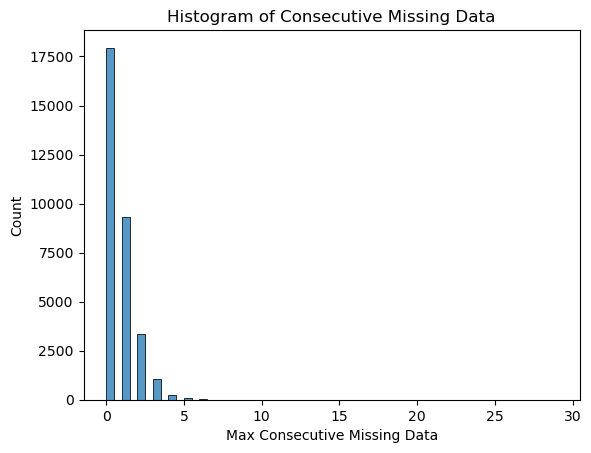

In [42]:
ax = sns.histplot(intra_ret_train_consecutive_missing, binwidth=0.5)
ax.set_title("Histogram of Consecutive Missing Data")
ax.set_xlabel("Max Consecutive Missing Data");

Seems like most of the rows have low to none of the amount of consecutive missing data. We can ignore the rows with high amount for now.

## Pattern of the Returns 

We have stated that there are 2 types of return that we need to forecast, intraday and interday. Let's take a look at the histogram of them. Initially, we can look at some samples of the intraday returns.

In [43]:
def plot_line_hist(df: pd.DataFrame, hist_xlim: tuple = None):
    nrows = df.shape[0]
    fig, axes = plt.subplots(nrows, 2, figsize=(8, 3 * nrows))
    for i, idx in enumerate(df.index):
        line_ax = axes[i, 0]
        hist_ax = axes[i, 1]
        sns.lineplot(df.loc[idx], ax=line_ax)
        sns.histplot(df.loc[idx], ax=hist_ax)
        line_ax.set_xticks([])
        hist_ax.set_xlabel("")
        if hist_xlim:
            hist_ax.set_xlim(*hist_xlim)

In [44]:
intra_ret_samples = train_df.loc[:, intra_ret_cols].sample(5, random_state=RANDOM_STATE)

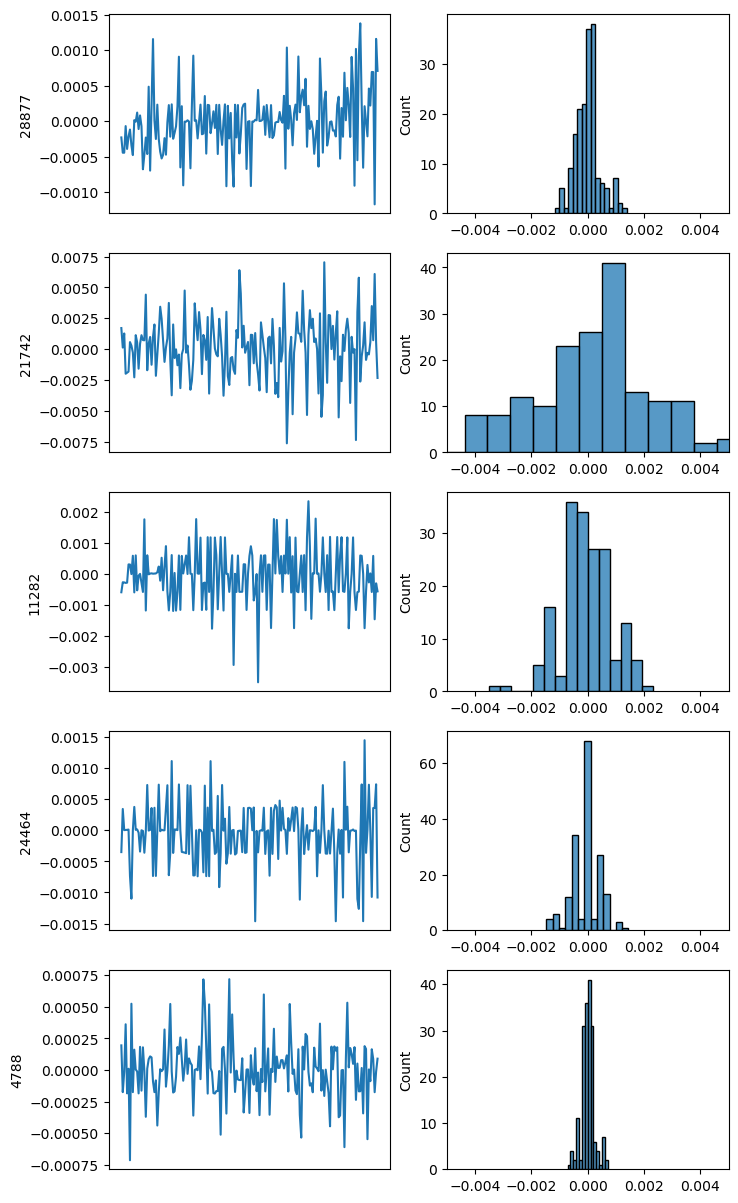

In [45]:
plot_line_hist(intra_ret_samples, hist_xlim=(-0.005, 0.005))

The charts shows that for the samples the returns are generally centered around 0. However, the variance might not be the same. What about some interday samples?

In [46]:
inter_ret_samples = train_df.loc[:, inter_ret_cols].sample(5, random_state=RANDOM_STATE)

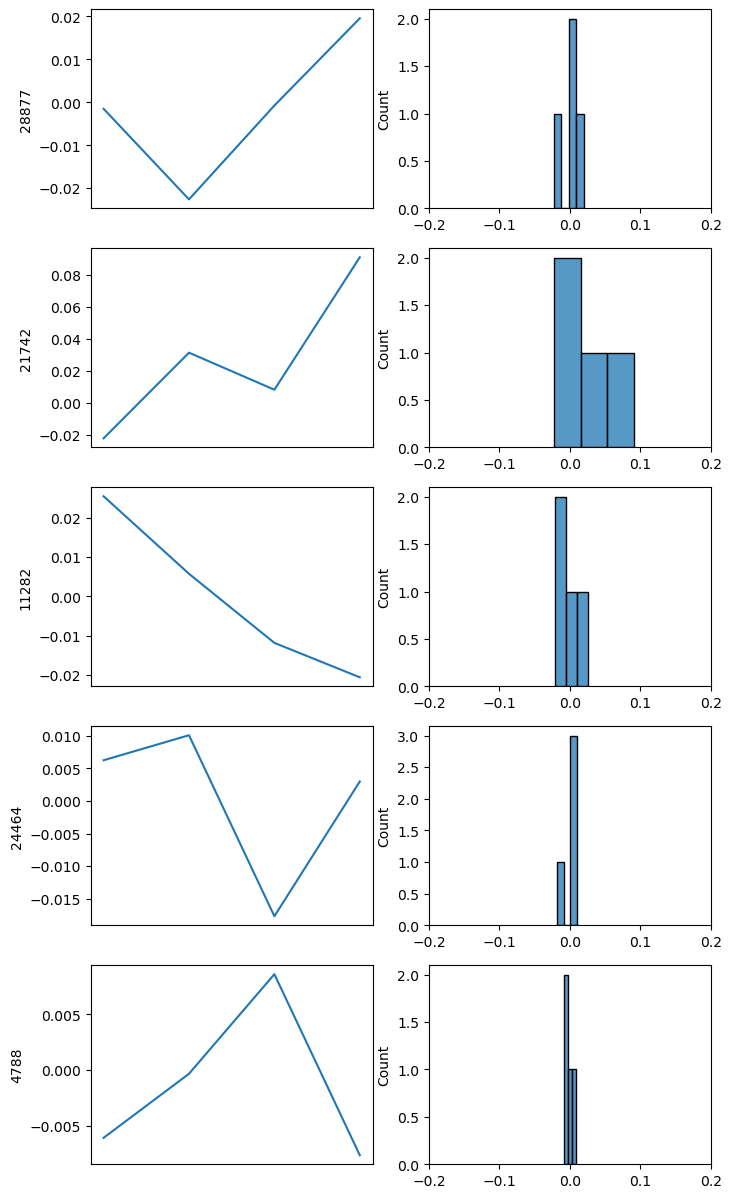

In [47]:
plot_line_hist(inter_ret_samples, hist_xlim=(-0.2, 0.2))

The pattern of interday returns is not clearly observed since there are only 5 days period per row. But from the chart we can see that there can be consecutive positive interday returns. What about average returns of the whole dataset?

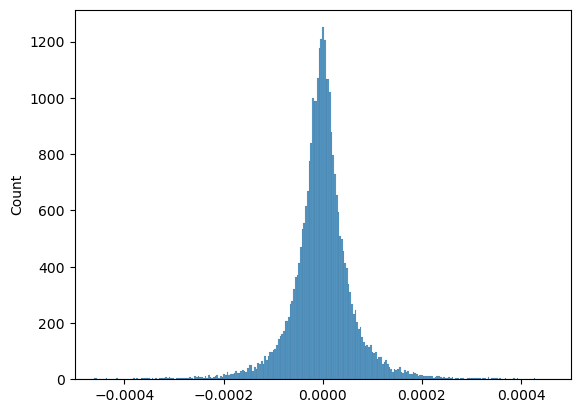

In [48]:
ax = sns.histplot(train_df.loc[:, intra_ret_cols].mean(axis=1))
ax.set_xlim(-0.0005, 0.0005);

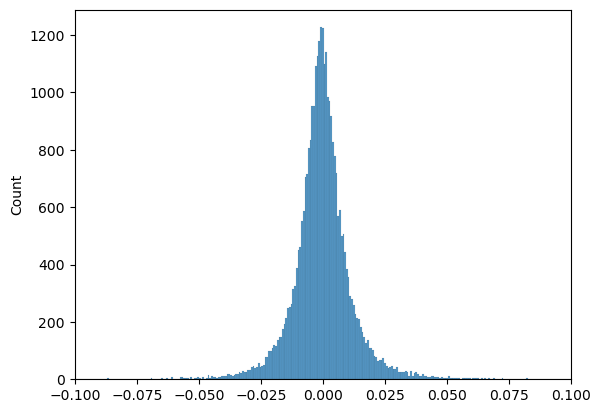

In [49]:
ax = sns.histplot(train_df.loc[:, inter_ret_cols].mean(axis=1))
ax.set_xlim(-0.1, 0.1);

The average returns of intraday and interday data are around 0 as expected. However, the variance between intraday and interday returns are not the same. This could be caused by the effect of cumulative returns across the days. 

## Correlations of the Features 

We are given some features apart from the returns which are Feature_1 to Feature_25. If we can find the subset of highly correlated features measured to out targets, we might get good candidates to be used in our modeling. But before that, we should look for correlations between the features themselves first.

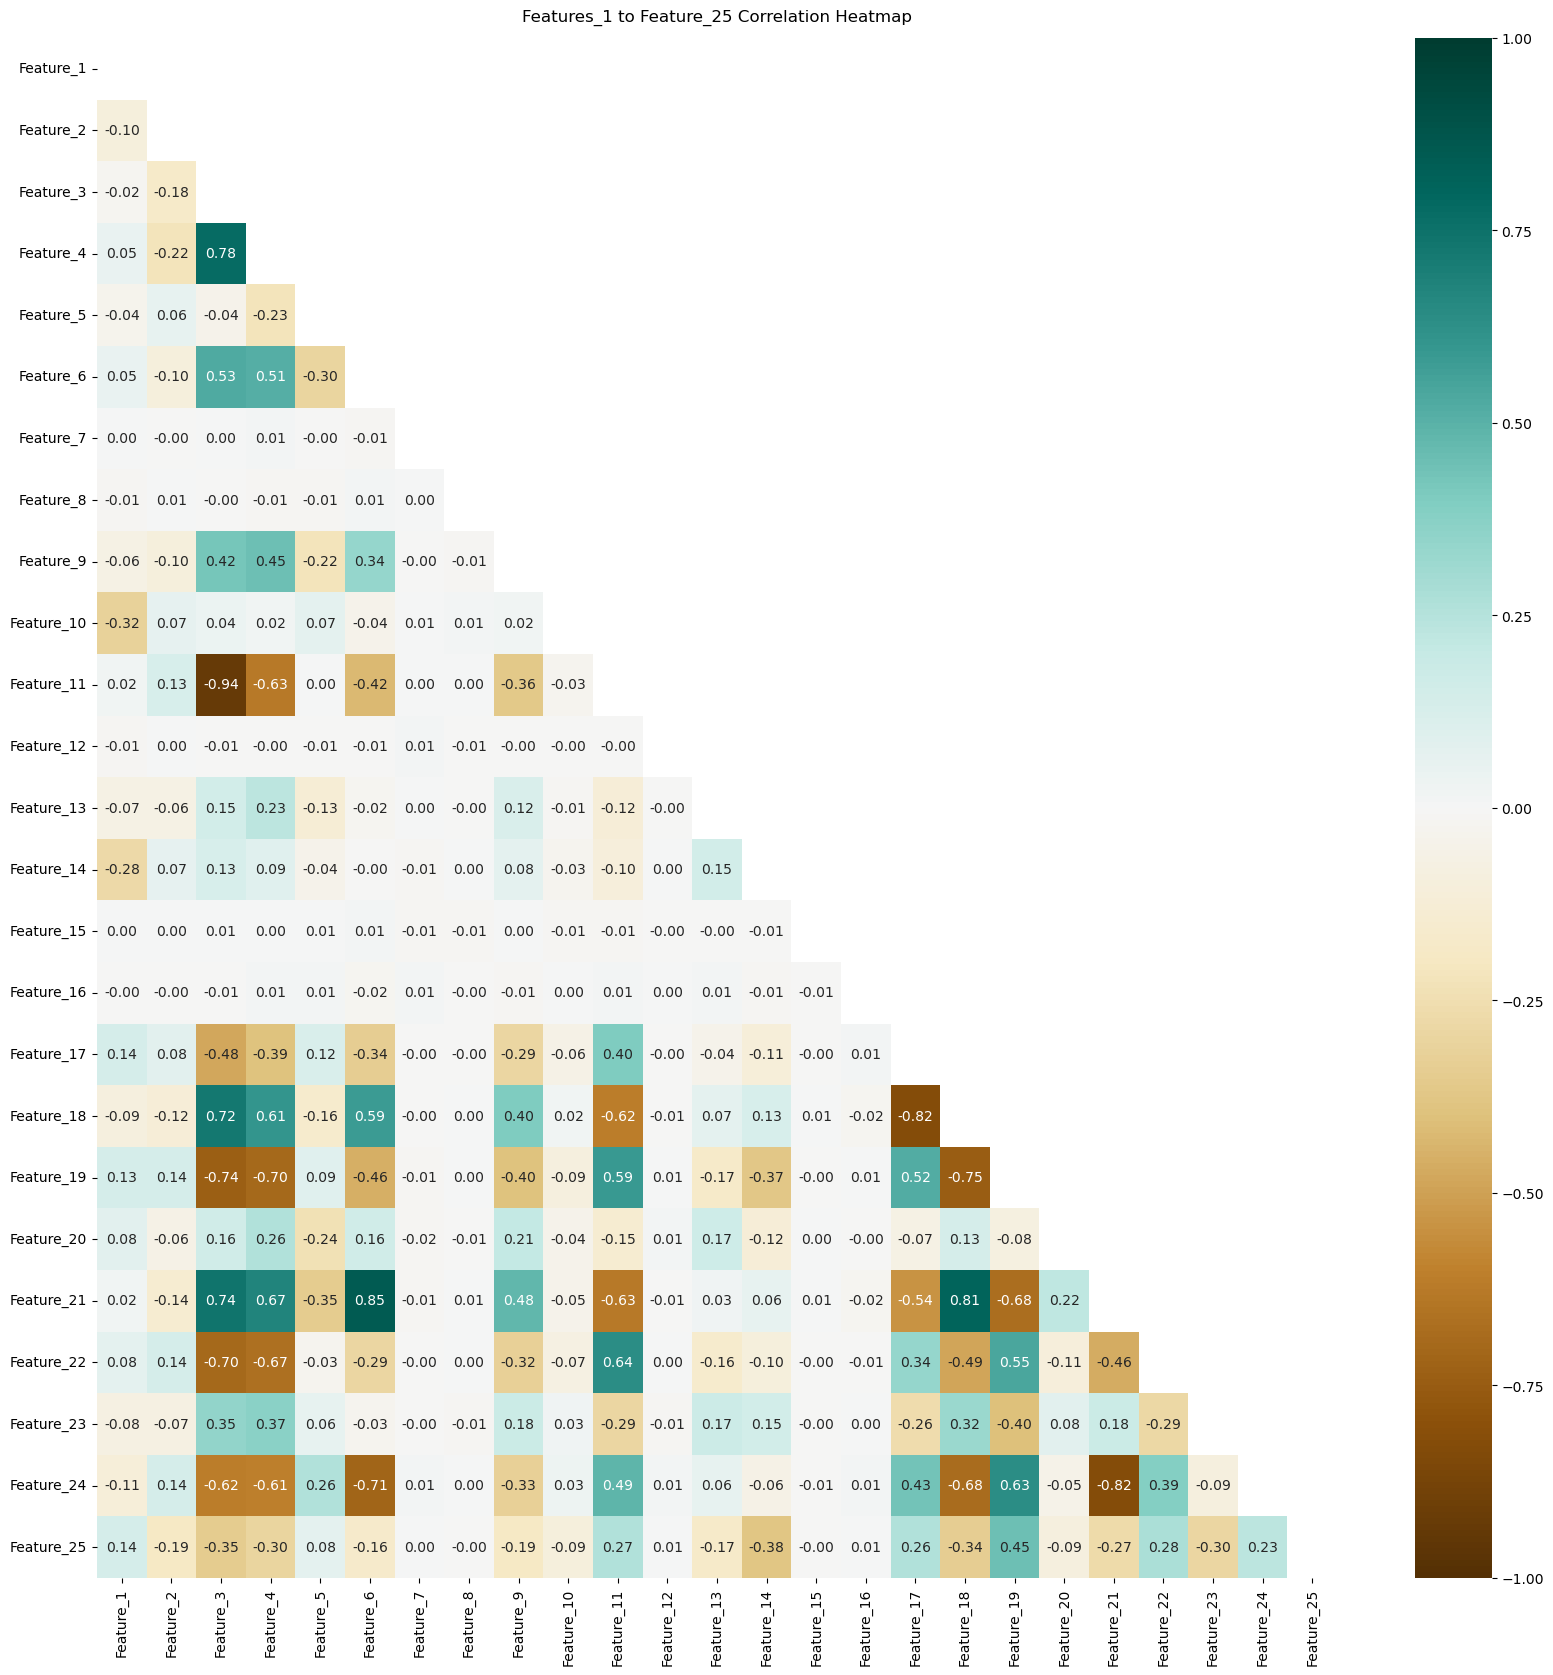

In [50]:
feature_corr_df = train_df.loc[:, feature_cols].corr()
mask = np.triu(np.ones_like(feature_corr_df, dtype=bool))
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
ax = sns.heatmap(feature_corr_df, vmin=-1, vmax=1, annot=True, mask=mask, cmap='BrBG', fmt=".2f")
ax.set_title('Features_1 to Feature_25 Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

Notably, the features with high correlation are
 - Feature_11 and Feature_3
 - Feature_21 and Feature_6
 - Feature_24 and Feature_21
 
 We can keep these features in mind when we interpret the coeficients of our regressor since multicollinearity might be present.

## Correlations of the Returns

Generally, a time series tend to correlate with itself on the past time lags. In this case, however, the given time series are given in disconnected chunks from different days. This means we can't just concatenate them and apply ACF and PACF. That doesn't mean these plots are not useful though. We can perform this operation on different rows and find if there are common time lags that have high correlation.

In [51]:
def plot_acf_pacf_row(df: pd.DataFrame):
    nrows = df.shape[0]
    fig, axes = plt.subplots(nrows, 2, figsize=(8, 3.2 * nrows))
    for i, idx in enumerate(df.index):
        acf_ax = axes[i, 0]
        pacf_ax = axes[i, 1]
        values = df.loc[idx].ffill().values.flatten() # ffill to make the plots work
        plot_acf(values, ax=acf_ax)
        plot_pacf(values, ax=pacf_ax, method='ywm')
        acf_ax.set_ylabel(idx)
        if i > 0:
            acf_ax.set_title("")
            pacf_ax.set_title("")

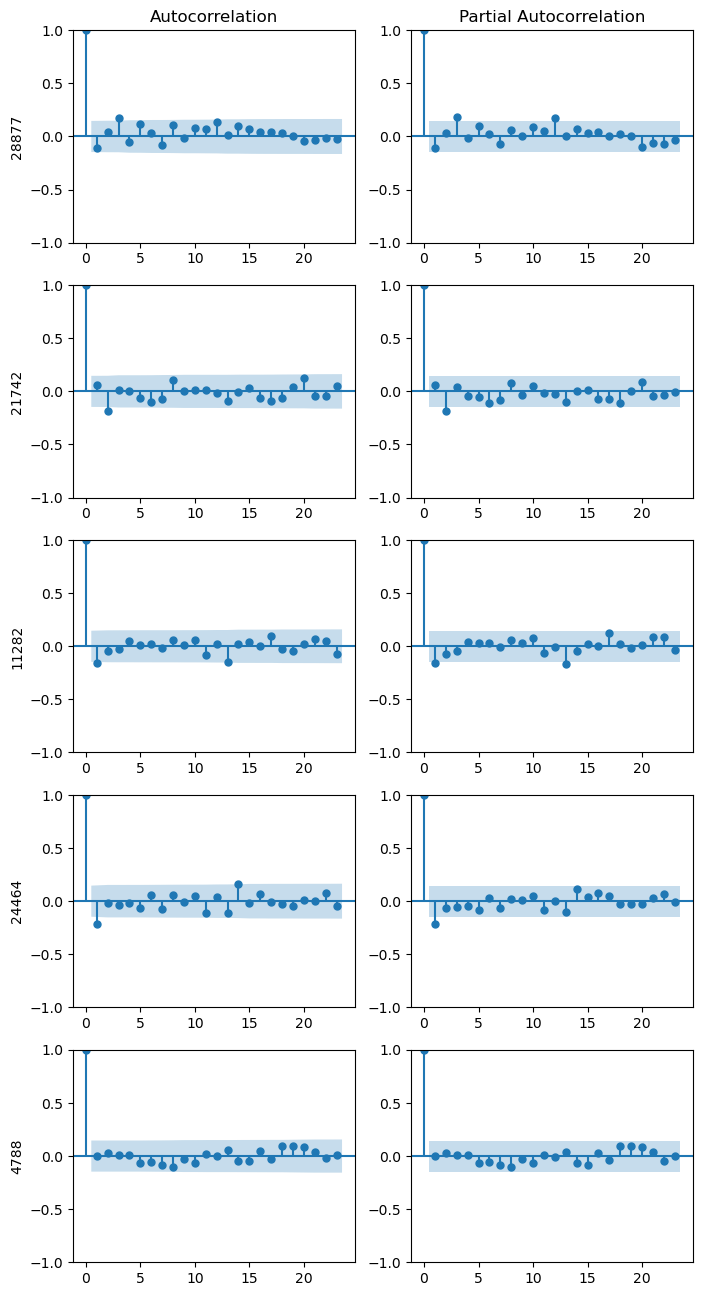

In [52]:
plot_acf_pacf_row(train_df.loc[:, intra_ret_cols].sample(5, random_state=RANDOM_STATE))

From the samples there are no clear time lag that shows high correlation. Not all hope is lost. We can aggregate the ACF and PACF results from every rows of all data and look for any time lags that frequently have high correlations. We'll limit the time lags to 20.

In [53]:
def get_acf_pacf_row(row: pd.Series, nlags: int = 20) -> pd.Series:
    values = row.ffill().values.flatten()
    acf_result = acf(values, nlags=nlags)
    pacf_result = pacf(values, nlags=nlags)
    acf_pacf_result = np.concatenate([acf_result, pacf_result])
    acf_index = [f"ACF_t-{i}" for i in range(nlags + 1)]
    pacf_index = [f"PACF_t-{i}" for i in range(nlags + 1)]
    index = acf_index + pacf_index
    result = pd.Series(acf_pacf_result, index=index)
    return result

In [54]:
intra_train_acf_pacf_df = train_df.loc[:, intra_ret_cols].apply(get_acf_pacf_row, axis=1)

In [55]:
intra_train_acf_df = intra_train_acf_pacf_df.loc[:, intra_train_acf_pacf_df.columns.str.startswith("ACF")]
intra_train_pacf_df = intra_train_acf_pacf_df.loc[:, intra_train_acf_pacf_df.columns.str.startswith("PACF")]

In [56]:
display_all_columns(intra_train_acf_df.head())

,ACF_t-0,ACF_t-1,ACF_t-2,ACF_t-3,ACF_t-4,ACF_t-5,ACF_t-6,ACF_t-7,ACF_t-8,ACF_t-9,ACF_t-10,ACF_t-11,ACF_t-12,ACF_t-13,ACF_t-14,ACF_t-15,ACF_t-16,ACF_t-17,ACF_t-18,ACF_t-19,ACF_t-20
0,1.0,0.109125,0.008563,-0.065712,-0.184880,0.074849,-0.018010,-0.004645,0.035790,0.009737,0.107662,0.077893,-0.021945,0.036567,0.095058,0.069245,0.040210,0.066995,-0.022509,-0.025458,-0.076116
2,1.0,-0.033359,-0.045647,-0.061291,0.000172,0.009618,0.113380,0.058079,0.064470,-0.014567,0.003937,-0.032308,-0.022905,-0.101830,0.011164,-0.012873,0.052596,-0.044900,-0.107811,0.027600,0.002124
3,1.0,-0.221828,0.054747,0.053695,-0.043313,0.002796,-0.055365,-0.043397,0.054128,-0.077431,-0.038979,0.061739,-0.054454,0.101948,-0.056256,-0.075758,0.015125,0.025644,-0.122734,0.018656,0.042011
5,1.0,-0.043865,0.009669,0.071523,-0.016402,-0.023567,-0.019109,-0.050746,0.040473,0.036385,-0.066807,-0.002388,-0.086386,-0.104818,-0.015714,0.157661,-0.100486,-0.024416,-0.035752,0.032005,-0.091177
6,1.0,-0.032628,-0.040714,0.013715,-0.136263,0.087976,0.046575,0.032523,-0.048596,-0.030141,0.106474,-0.046369,0.036751,-0.049176,-0.029503,-0.006515,-0.001249,0.172088,-0.053566,0.034558,0.014072


In [57]:
display_all_columns(intra_train_pacf_df.head())

,PACF_t-0,PACF_t-1,PACF_t-2,PACF_t-3,PACF_t-4,PACF_t-5,PACF_t-6,PACF_t-7,PACF_t-8,PACF_t-9,PACF_t-10,PACF_t-11,PACF_t-12,PACF_t-13,PACF_t-14,PACF_t-15,PACF_t-16,PACF_t-17,PACF_t-18,PACF_t-19,PACF_t-20
0,1.0,0.109738,-0.003424,-0.068233,-0.177262,0.121464,-0.043457,-0.022826,0.019102,0.041091,0.090612,0.066033,-0.030309,0.062371,0.148311,0.059331,0.013539,0.122778,0.000045,-0.027787,-0.084723
2,1.0,-0.033546,-0.047342,-0.065767,-0.006759,0.003538,0.114296,0.071137,0.087477,0.013216,0.020551,-0.028092,-0.044395,-0.139216,-0.035136,-0.047537,0.034328,-0.039703,-0.108815,0.064242,0.018524
3,1.0,-0.223074,0.005897,0.071778,-0.018371,-0.016898,-0.065498,-0.070690,0.039540,-0.051735,-0.076754,0.037148,-0.027216,0.091224,-0.025940,-0.119199,-0.054821,0.052039,-0.115038,-0.051627,0.057792
5,1.0,-0.044112,0.007848,0.073664,-0.010488,-0.027172,-0.027270,-0.052692,0.042331,0.046836,-0.062579,-0.018913,-0.102153,-0.114129,-0.024343,0.198258,-0.082431,-0.064540,-0.086209,0.042545,-0.095843
6,1.0,-0.032812,-0.042296,0.011185,-0.140687,0.084253,0.041455,0.048531,-0.068436,-0.008163,0.114308,-0.042530,0.022374,-0.061808,0.010839,-0.041461,0.002457,0.171563,-0.038866,0.055676,0.002054


Now that we got the ACF and PACF results, let's see the box plots of every time lags!

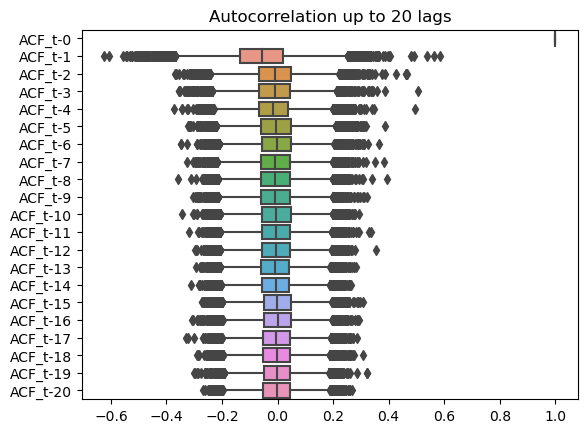

In [58]:
ax = sns.boxplot(intra_train_acf_df, orient="h")
ax.set_title("Autocorrelation up to 20 lags");

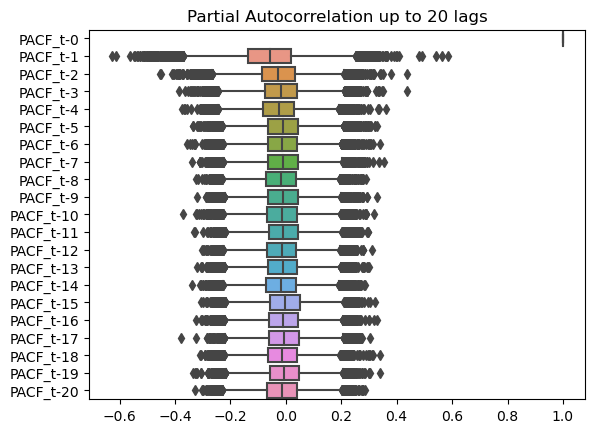

In [59]:
ax = sns.boxplot(intra_train_pacf_df, orient="h")
ax.set_title("Partial Autocorrelation up to 20 lags");

The plot show that there's only the first time lag that generally has ralatively higher correlation. We can use this to decide the length of our lookback window. Now, let's see the interday returns. Keep in mind that the interday returns we have only 2 past returns and 2 future returns to be forecasted.

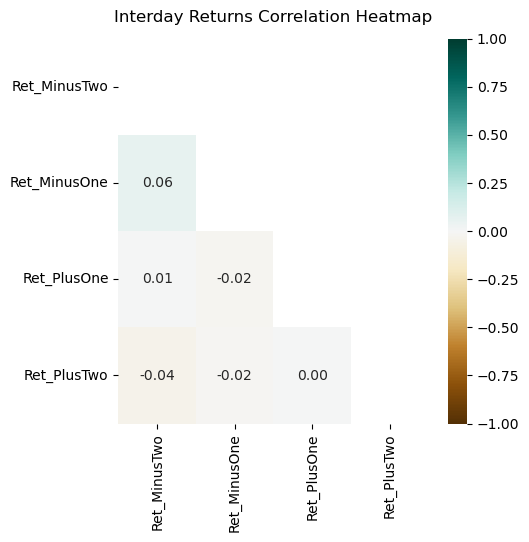

In [60]:
inter_corr_df = train_df.loc[:, inter_ret_cols].corr()
mask = np.triu(np.ones_like(inter_corr_df, dtype=bool))
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = sns.heatmap(inter_corr_df, vmin=-1, vmax=1, annot=True, mask=mask, cmap='BrBG', fmt=".2f")
ax.set_title('Interday Returns Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

There are no high correlations between the interday returns. Coupled with the fact that there are only 2 past daily returns, we might not need to use complex models.

## Correlation of the Features to the Targets

Since the goal is to forecast 60 intraday returns and 2 interday returns, that means if we treat them as individual forecasting targets we can find the correlation between Feature_1 to Feature_25 and each forecasting target separately. However, the intraday returns are not specified to be taken from the same time everyday. We can summarize the intraday returns before finding the correlation.

In [61]:
feature_target_df = train_df.loc[:, feature_cols + inter_ret_target_cols]
display_all_columns(feature_target_df.head())

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Ret_PlusOne,Ret_PlusTwo
0,NaN,NaN,NaN,NaN,8.0,NaN,75751,0.2254,11.0,NaN,NaN,0.49,5.0,1.842984,27.053679,1.0,NaN,NaN,-0.925463,2.0,NaN,-0.489492,NaN,NaN,NaN,-0.019512,0.028846
2,NaN,-0.696727,0.739591,-0.167928,9.0,0.471947,8277,0.3650,9.0,5.0,-0.473024,0.03,6.0,1.871160,9.647559,1.0,-1.132426,1.799813,-1.603488,3.0,NaN,0.389061,1.728096,-1.798090,-1.019370,-0.024791,0.015711
3,NaN,-0.694350,1.568248,0.479073,5.0,0.120653,22508,0.2654,13.0,5.0,-2.138383,0.00,6.0,NaN,1.801865,1.0,-1.131213,1.565036,NaN,7.0,1.148738,-2.440799,1.551425,-1.788725,NaN,-0.005680,-0.002190
5,NaN,NaN,-0.680515,NaN,1.0,0.227034,24099,0.2064,8.0,NaN,0.668207,0.65,1.0,1.607182,1.059815,1.0,-0.587538,0.230375,-0.897600,10.0,0.111960,1.670980,0.364626,1.039643,-0.404685,0.031098,-0.006551
6,NaN,-0.230636,-0.227021,-0.084126,7.0,-0.095007,39351,0.3650,13.0,NaN,0.614787,0.85,7.0,1.829130,0.525992,1.0,-0.140953,0.016076,-0.966690,3.0,-0.186534,1.080087,0.799836,-0.753148,-0.440274,-0.011105,-0.030745


In [62]:
feature_target_df["Intraday Mean Return"] = train_df.loc[:, intra_ret_feat_cols].mean(axis=1)
display_all_columns(feature_target_df.head())

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Ret_PlusOne,Ret_PlusTwo,Intraday Mean Return
0,NaN,NaN,NaN,NaN,8.0,NaN,75751,0.2254,11.0,NaN,NaN,0.49,5.0,1.842984,27.053679,1.0,NaN,NaN,-0.925463,2.0,NaN,-0.489492,NaN,NaN,NaN,-0.019512,0.028846,-0.000245
2,NaN,-0.696727,0.739591,-0.167928,9.0,0.471947,8277,0.3650,9.0,5.0,-0.473024,0.03,6.0,1.871160,9.647559,1.0,-1.132426,1.799813,-1.603488,3.0,NaN,0.389061,1.728096,-1.798090,-1.019370,-0.024791,0.015711,-0.000005
3,NaN,-0.694350,1.568248,0.479073,5.0,0.120653,22508,0.2654,13.0,5.0,-2.138383,0.00,6.0,NaN,1.801865,1.0,-1.131213,1.565036,NaN,7.0,1.148738,-2.440799,1.551425,-1.788725,NaN,-0.005680,-0.002190,0.000011
5,NaN,NaN,-0.680515,NaN,1.0,0.227034,24099,0.2064,8.0,NaN,0.668207,0.65,1.0,1.607182,1.059815,1.0,-0.587538,0.230375,-0.897600,10.0,0.111960,1.670980,0.364626,1.039643,-0.404685,0.031098,-0.006551,0.000130
6,NaN,-0.230636,-0.227021,-0.084126,7.0,-0.095007,39351,0.3650,13.0,NaN,0.614787,0.85,7.0,1.829130,0.525992,1.0,-0.140953,0.016076,-0.966690,3.0,-0.186534,1.080087,0.799836,-0.753148,-0.440274,-0.011105,-0.030745,0.000051


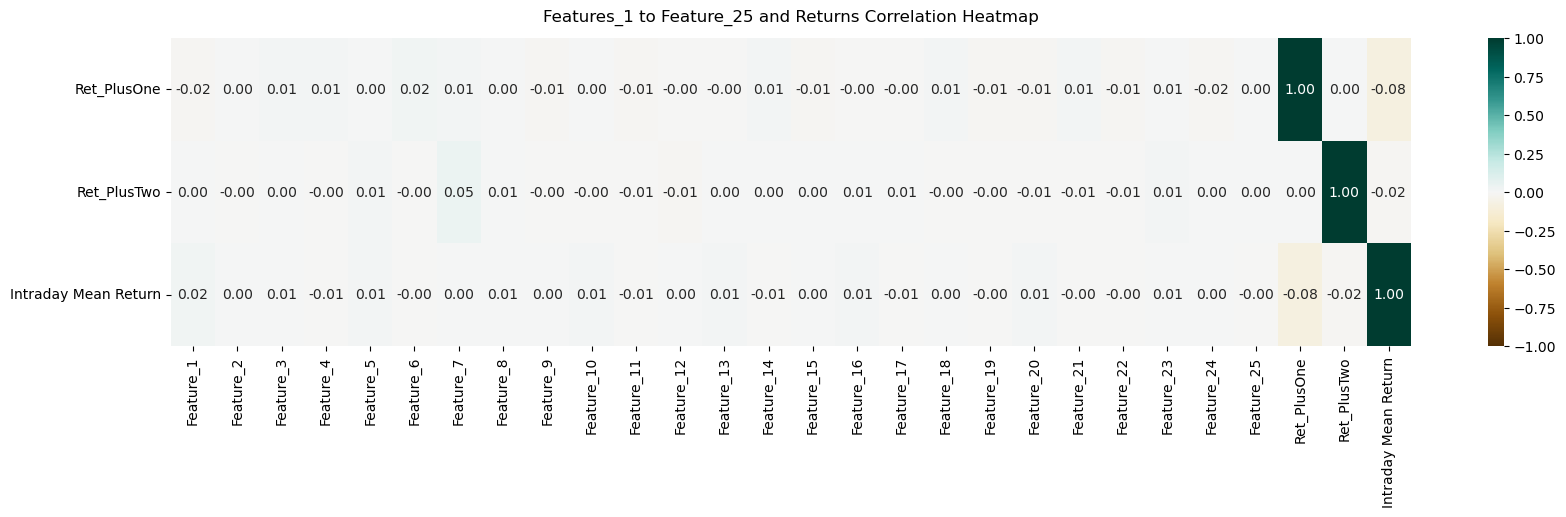

In [63]:
feature_target_corr_df = feature_target_df.corr().drop(feature_cols)
fig, ax = plt.subplots(1, 1, figsize=(20, 4))
ax = sns.heatmap(feature_target_corr_df, vmin=-1, vmax=1, annot=True, cmap='BrBG', fmt=".2f")
ax.set_title('Features_1 to Feature_25 and Returns Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

The result shows that the correlations between Feature_1 to Feature_25 and the returns data are low for both the intraday mean and interday.

# Data Preprocessing 🏭

From our data analysis we can initially use a subset of features and see the result first. For this first experiment, let's go for the simplest kind of forecasting which is direct forecasting. The features we are going to use are
- Time lags up to t-10 for intraday
- All time lags for interday
- Feature_1 to Feature_25 (drop Feature_1 and Feature_10 since they have high amount of missing data)

In [64]:
selected_feature_cols = [f"Feature_{i}" for i in range(1, 26) if i not in [1, 10]]

In [65]:
selected_intra_cols = selected_feature_cols + intra_ret_feat_cols[-10:]
selected_intra_cols

['Feature_2',
 'Feature_3',
 'Feature_4',
 'Feature_5',
 'Feature_6',
 'Feature_7',
 'Feature_8',
 'Feature_9',
 'Feature_11',
 'Feature_12',
 'Feature_13',
 'Feature_14',
 'Feature_15',
 'Feature_16',
 'Feature_17',
 'Feature_18',
 'Feature_19',
 'Feature_20',
 'Feature_21',
 'Feature_22',
 'Feature_23',
 'Feature_24',
 'Feature_25',
 'Ret_111',
 'Ret_112',
 'Ret_113',
 'Ret_114',
 'Ret_115',
 'Ret_116',
 'Ret_117',
 'Ret_118',
 'Ret_119',
 'Ret_120']

In [66]:
selected_inter_cols = selected_feature_cols + inter_ret_feat_cols
selected_inter_cols

['Feature_2',
 'Feature_3',
 'Feature_4',
 'Feature_5',
 'Feature_6',
 'Feature_7',
 'Feature_8',
 'Feature_9',
 'Feature_11',
 'Feature_12',
 'Feature_13',
 'Feature_14',
 'Feature_15',
 'Feature_16',
 'Feature_17',
 'Feature_18',
 'Feature_19',
 'Feature_20',
 'Feature_21',
 'Feature_22',
 'Feature_23',
 'Feature_24',
 'Feature_25',
 'Ret_MinusTwo',
 'Ret_MinusOne']

## Feature_n Imputation

Since Feature_1 through Feature_25 all have numerical data, we can impute using mean.

In [67]:
feature_imputer = Imputer(method="mean")

In [68]:
imputed_train_feature_df = feature_imputer.fit_transform(train_df.loc[:, selected_feature_cols])

In [69]:
display_all_columns(imputed_train_feature_df.head())

,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25
0,-0.115652,0.562882,0.407536,8.0,0.438461,75751,0.2254,11.0,-0.578247,0.49,5.0,1.842984,27.053679,1.0,-0.551236,0.808360,-0.925463,2.0,0.610530,-0.489492,0.798795,-1.212693,-0.327696
2,-0.696727,0.739591,-0.167928,9.0,0.471947,8277,0.3650,9.0,-0.473024,0.03,6.0,1.871160,9.647559,1.0,-1.132426,1.799813,-1.603488,3.0,0.610530,0.389061,1.728096,-1.798090,-1.019370
3,-0.694350,1.568248,0.479073,5.0,0.120653,22508,0.2654,13.0,-2.138383,0.00,6.0,1.588420,1.801865,1.0,-1.131213,1.565036,-1.205745,7.0,1.148738,-2.440799,1.551425,-1.788725,-0.327696
5,-0.115652,-0.680515,0.407536,1.0,0.227034,24099,0.2064,8.0,0.668207,0.65,1.0,1.607182,1.059815,1.0,-0.587538,0.230375,-0.897600,10.0,0.111960,1.670980,0.364626,1.039643,-0.404685
6,-0.230636,-0.227021,-0.084126,7.0,-0.095007,39351,0.3650,13.0,0.614787,0.85,7.0,1.829130,0.525992,1.0,-0.140953,0.016076,-0.966690,3.0,-0.186534,1.080087,0.799836,-0.753148,-0.440274


In [70]:
imputed_test_feature_df = feature_imputer.transform(test_df.loc[:, selected_feature_cols])

In [71]:
display_all_columns(imputed_test_feature_df.head())

,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25
1,-0.115652,0.562882,0.407536,3.0,0.388896,17369,0.0166,13.0,-0.409923,0.71,9.0,1.577586,9.546915,1.0,-0.949891,0.917958,-0.897067,9.000000,0.886205,-0.151805,1.239856,0.953424,-0.709462
4,-1.736489,2.765531,1.245280,7.0,4.866985,22423,0.2138,13.0,-4.795565,0.97,5.0,0.842102,9.198895,1.0,6.317498,-3.208872,-1.102189,7.000000,3.381040,1.732708,1.965189,-5.993092,3.219820
7,2.582955,0.157344,0.617261,8.0,-0.177333,92214,0.2119,8.0,0.302677,0.48,3.0,1.489166,0.262896,1.0,-0.788162,0.951173,-1.896213,5.270921,0.264332,0.014091,1.071300,-2.083937,-0.706392
13,0.480362,0.915407,1.381156,7.0,0.223401,35023,0.2138,10.0,-1.219864,0.89,5.0,1.848343,0.166849,1.0,-0.592927,0.682742,-1.347018,4.000000,0.352247,0.586843,0.907012,-2.096931,-0.844257
23,-1.833909,0.807421,0.396305,7.0,0.225614,57773,0.2986,7.0,-0.965748,0.34,0.0,1.189478,0.496784,1.0,-0.800207,0.811756,-0.564181,9.000000,0.303550,0.180322,1.147526,-0.111506,2.704840


## Intraday Imputation

In [72]:
intra_imputer = Imputer(method="ffill")

In [73]:
imputed_train_intra_df = intra_imputer.fit_transform(train_df.loc[:, intra_ret_feat_cols])

In [74]:
display_all_columns(imputed_train_intra_df.head())

,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,Ret_10,Ret_11,Ret_12,Ret_13,Ret_14,Ret_15,Ret_16,Ret_17,Ret_18,Ret_19,Ret_20,Ret_21,Ret_22,Ret_23,Ret_24,Ret_25,Ret_26,Ret_27,Ret_28,Ret_29,Ret_30,Ret_31,Ret_32,Ret_33,Ret_34,Ret_35,Ret_36,Ret_37,Ret_38,Ret_39,Ret_40,Ret_41,Ret_42,Ret_43,Ret_44,Ret_45,Ret_46,Ret_47,Ret_48,Ret_49,Ret_50,Ret_51,Ret_52,Ret_53,Ret_54,Ret_55,Ret_56,Ret_57,Ret_58,Ret_59,Ret_60,Ret_61,Ret_62,Ret_63,Ret_64,Ret_65,Ret_66,Ret_67,Ret_68,Ret_69,Ret_70,Ret_71,Ret_72,Ret_73,Ret_74,Ret_75,Ret_76,Ret_77,Ret_78,Ret_79,Ret_80,Ret_81,Ret_82,Ret_83,Ret_84,Ret_85,Ret_86,Ret_87,Ret_88,Ret_89,Ret_90,Ret_91,Ret_92,Ret_93,Ret_94,Ret_95,Ret_96,Ret_97,Ret_98,Ret_99,Ret_100,Ret_101,Ret_102,Ret_103,Ret_104,Ret_105,Ret_106,Ret_107,Ret_108,Ret_109,Ret_110,Ret_111,Ret_112,Ret_113,Ret_114,Ret_115,Ret_116,Ret_117,Ret_118,Ret_119,Ret_120
0,2.954272e-06,-0.000734,-0.000738,-0.000007,0.000423,0.000438,-0.000076,6.446240e-04,-0.000006,0.000006,-0.000930,-0.000156,0.000663,0.000787,-0.000430,-1.964625e-05,0.000002,-0.000031,0.000003,0.000141,-0.000008,0.000532,0.000416,-0.000164,-0.000009,-0.000438,-0.000268,0.000010,-7.176461e-04,-0.000162,-0.000399,-0.000388,0.000025,-0.000582,0.001003,-0.000010,0.000134,0.000014,-0.000142,-0.001003,-0.000007,-0.000005,-0.000013,-0.000252,0.000706,-0.000734,-0.000731,-0.001996,-0.000153,0.000133,-0.000528,0.000530,-0.000007,0.000713,0.000009,-0.000003,-0.000432,-0.001152,-0.000723,9.982299e-07,-0.003579,0.000435,-0.000012,-1.320877e-04,0.000004,0.000418,-0.000011,-1.309833e-04,-2.723725e-03,-0.002996,0.000129,0.000012,-1.757219e-06,-0.000137,-0.003537,-0.000142,0.000135,0.000020,-1.318606e-04,0.000449,-0.000008,0.000006,0.000282,-0.000139,-0.000128,0.000005,-0.000005,-1.693501e-03,-0.002141,0.000003,-0.000274,-0.000015,0.001279,0.000282,-0.000003,-0.000156,0.000024,-0.000560,-0.000580,0.000138,-0.002277,0.000125,0.000406,-0.000427,-0.000013,-0.000843,0.000167,0.000569,0.000695,0.000250,0.000700,-0.000843,0.000268,-0.000415,-0.001133,0.000004,-0.000137,-0.000009,0.000134
2,-7.822703e-04,-0.000402,0.000807,0.000400,0.000656,-0.001177,0.001198,6.100221e-04,-0.001031,0.000647,-0.000930,-0.000543,0.000663,0.000787,0.000390,1.348995e-04,0.000122,-0.000133,0.000003,0.000141,0.000538,0.000532,0.000106,0.000106,-0.000261,0.000125,-0.000268,-0.000404,-7.805902e-04,0.000270,-0.000399,-0.000388,0.000025,-0.000500,-0.000909,0.000532,-0.000908,-0.000007,-0.000780,-0.000140,-0.000530,0.000142,0.000518,-0.000252,0.000130,0.000384,0.000648,0.000115,0.000767,-0.000911,-0.000528,0.000530,-0.000278,-0.000776,-0.000128,-0.000003,0.000139,-0.000284,-0.000144,-3.869633e-04,-0.000651,-0.000139,0.000780,5.164489e-04,-0.001057,-0.000640,0.000660,-1.309833e-04,1.062824e-05,-0.000274,-0.000796,0.000510,-3.820386e-04,0.000133,-0.000386,-0.000011,-0.000525,0.001158,5.364737e-07,-0.000269,0.000135,0.000388,0.000660,0.000135,-0.000392,0.000256,-0.000538,3.916393e-04,-0.000267,0.000143,0.000127,0.000118,-0.000406,0.000004,0.000366,-0.000133,-0.000272,0.000013,-0.000134,0.000654,-0.000129,0.000517,0.000271,0.000370,-0.000011,0.000532,0.000513,0.000393,-0.000273,0.000250,-0.000138,-0.000266,0.000786,0.001702,-0.000271,-0.000530,-0.000666,-0.000270,-0.000372
3,2.773425e-04,-0.000088,-0.000199,-0.000301,0.000711,-0.000431,-0.000144,3.404036e-04,-0.000639,0.000420,0.000145,-0.000130,0.000589,0.000410,0.000134,6.039066e-07,-0.000266,0.000071,-0.000058,-0.000710,0.000285,-0.000141,0.000003,0.000281,0.000012,0.000001,-0.000291,0.000003,-9.865118e-07,-0.000283,0.000290,-0.000153,0.000015,-0.000007,-0.000417,0.000145,-0.000295,-0.000282,-0.000150,-0.000141,0.000558,0.000061,0.000518,0.000303,0.000332,-0.000164,0.000011,0.000285,0.000148,-0.000132,-0.000107,-0.000166,0.000268,-0.000560,0.000203,-0.000003,-0.000127,-0.000076,-0.000294,1.790711e-05,0.000418,0.000083,-0.000208,7.080493e-04,-0.000369,0.000362,-0.000004,6.728819e-05,-7.099829e-05,-0.000274,0.000282,0.000301,-1.750760e-05,0.000124,0.000281,0.000157,-0.000001,-0.000430,-1.475570e-0

In [75]:
imputed_test_intra_df = intra_imputer.transform(test_df.loc[:, intra_ret_feat_cols])

In [76]:
display_all_columns(imputed_test_intra_df.head())

,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,Ret_10,Ret_11,Ret_12,Ret_13,Ret_14,Ret_15,Ret_16,Ret_17,Ret_18,Ret_19,Ret_20,Ret_21,Ret_22,Ret_23,Ret_24,Ret_25,Ret_26,Ret_27,Ret_28,Ret_29,Ret_30,Ret_31,Ret_32,Ret_33,Ret_34,Ret_35,Ret_36,Ret_37,Ret_38,Ret_39,Ret_40,Ret_41,Ret_42,Ret_43,Ret_44,Ret_45,Ret_46,Ret_47,Ret_48,Ret_49,Ret_50,Ret_51,Ret_52,Ret_53,Ret_54,Ret_55,Ret_56,Ret_57,Ret_58,Ret_59,Ret_60,Ret_61,Ret_62,Ret_63,Ret_64,Ret_65,Ret_66,Ret_67,Ret_68,Ret_69,Ret_70,Ret_71,Ret_72,Ret_73,Ret_74,Ret_75,Ret_76,Ret_77,Ret_78,Ret_79,Ret_80,Ret_81,Ret_82,Ret_83,Ret_84,Ret_85,Ret_86,Ret_87,Ret_88,Ret_89,Ret_90,Ret_91,Ret_92,Ret_93,Ret_94,Ret_95,Ret_96,Ret_97,Ret_98,Ret_99,Ret_100,Ret_101,Ret_102,Ret_103,Ret_104,Ret_105,Ret_106,Ret_107,Ret_108,Ret_109,Ret_110,Ret_111,Ret_112,Ret_113,Ret_114,Ret_115,Ret_116,Ret_117,Ret_118,Ret_119,Ret_120
1,-0.000487,0.000475,0.000002,-0.000002,-0.000523,-0.000255,-0.000008,0.000048,-0.000312,-0.000742,-0.000009,-0.000248,0.000487,0.000256,-0.000508,0.000250,0.000015,0.000008,-0.000251,-0.000519,-5.029784e-04,0.000240,0.000248,4.947589e-04,-0.000243,-0.000252,-2.519636e-04,-0.000230,0.000212,-0.000503,-0.000014,-0.000008,0.000241,0.000017,-0.000254,0.000250,-0.000250,-2.541045e-06,-0.000254,-0.000006,-0.001000,0.000244,-5.060288e-04,0.000490,-0.000503,0.000241,2.252539e-05,5.075899e-04,-0.000241,0.000244,0.000354,-0.000575,0.000266,0.000253,0.000238,-0.000002,4.446670e-04,-0.000180,-0.000228,-0.000767,-0.000260,-0.000002,-0.000490,-0.000266,-0.000243,-0.000248,-0.000730,-0.000246,-0.000102,0.000363,-0.000506,-0.000247,-0.000004,8.426020e-07,-0.000740,-0.000509,-0.000004,-0.000745,-0.000503,0.000244,0.000006,0.000750,0.000745,2.358982e-04,2.546037e-04,0.000001,-0.000118,-0.000124,-0.000012,-0.000017,-0.000728,-0.000489,0.000743,-5.069956e-04,0.000003,-1.226296e-04,-1.325195e-04,0.000753,-0.000003,-0.000264,-0.000118,0.000244,-0.000377,-0.000007,-0.000486,0.000745,-7.091554e-07,-0.000240,0.000230,-0.000010,2.494024e-04,0.000492,-0.000022,0.000046,-0.000294,-0.000366,-0.000125,-0.000007,2.558108e-04
4,-0.001232,0.000002,-0.001205,-0.000021,0.000005,0.000623,-0.001843,0.000005,0.001226,0.001213,-0.002428,0.000974,0.000249,-0.001217,0.001220,0.000024,-0.000017,-0.001246,0.001220,-0.000006,4.624901e-07,-0.001222,-0.000001,1.228060e-03,0.001220,-0.001213,1.217567e-03,-0.001215,0.001226,-0.000015,0.000002,-0.000002,-0.000005,0.000004,0.001217,0.000003,-0.000022,-7.422013e-06,0.000002,-0.000008,-0.000009,-0.000006,-9.126965e-07,0.000005,0.000009,-0.000005,-1.239919e-07,4.326580e-06,0.000007,-0.001222,-0.001221,0.001228,-0.000005,0.000001,0.001219,-0.000240,2.631727e-04,0.000020,0.000004,-0.000002,0.000007,-0.000361,0.000378,-0.001212,0.001230,0.000004,-0.000007,0.000008,0.000012,-0.001233,-0.001211,0.001229,-0.000001,-1.596883e-03,0.000363,-0.000019,-0.001202,0.001234,0.000001,-0.001209,-0.000018,0.000007,-0.000003,4.432056e-07,3.499550e-07,0.001203,0.000014,-0.000013,-0.001220,-0.000007,-0.000008,-0.001205,0.000256,-2.482979e-04,0.000750,-7.317127e-04,1.218458e-03,0.000021,0.000009,-0.001201,-0.001196,0.001213,-0.001214,0.001227,0.000026,-0.000005,2.430941e-03,-0.001192,0.000008,-0.000014,1.209899e-03,0.000011,-0.000005,-0.000011,0.000003,-0.001229,-0.000003,0.001208,-4.473375e-07
7,0.000176,0.000558,-0.000007,0.000005,-0.000016,-0.000247,0.000071,0.000167,-0.000729,0.000257,0.000002,-0.000986,0.000236,-0.000507,0.000004,-0.000238,-0.000254,0.000003,-0.000215,-0.000044,2.499140e-04,0.000244,0.000011,3.857622e-07,0.000497,0.000249,-2.365839e-04,-0.000242,-0.000006,-0.000263,0.000241,-0.000247,-0.000006,0.000251,0.000005,0.000007,0.000012,4.167173e-07,0.000010,0.000016,-0.000744,-0.001504,4.835785e-04,-0.000504,0.000002,0.000682,-1.723839e-04,-7.902223e-04,0.000476,-0.000234,0.000003,0.000011,0.000014,0.000008,0.000235,-0.000004,-3.532657e-08,0.000252,0.000245,-0.001490,0.000494,0.000030,-0.000004,0.000747,-0.000034,-0.000216,-0.000503,0.000267,0.000491,0.001236,0.000495,-0.000244,-0.000491,-2.541025e-04,-0

## Features for Intraday Forecasting

Now we can combine the features and intraday returns.

In [77]:
X_train_intra = pd.concat([imputed_train_feature_df, imputed_train_intra_df.iloc[:, -10:]], axis=1)

In [78]:
display_all_columns(X_train_intra.head())

,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Ret_111,Ret_112,Ret_113,Ret_114,Ret_115,Ret_116,Ret_117,Ret_118,Ret_119,Ret_120
0,-0.115652,0.562882,0.407536,8.0,0.438461,75751,0.2254,11.0,-0.578247,0.49,5.0,1.842984,27.053679,1.0,-0.551236,0.808360,-0.925463,2.0,0.610530,-0.489492,0.798795,-1.212693,-0.327696,0.000250,0.000700,-0.000843,0.000268,-0.000415,-0.001133,0.000004,-0.000137,-0.000009,0.000134
2,-0.696727,0.739591,-0.167928,9.0,0.471947,8277,0.3650,9.0,-0.473024,0.03,6.0,1.871160,9.647559,1.0,-1.132426,1.799813,-1.603488,3.0,0.610530,0.389061,1.728096,-1.798090,-1.019370,0.000250,-0.000138,-0.000266,0.000786,0.001702,-0.000271,-0.000530,-0.000666,-0.000270,-0.000372
3,-0.694350,1.568248,0.479073,5.0,0.120653,22508,0.2654,13.0,-2.138383,0.00,6.0,1.588420,1.801865,1.0,-1.131213,1.565036,-1.205745,7.0,1.148738,-2.440799,1.551425,-1.788725,-0.327696,-0.000571,0.000288,0.000006,0.000148,-0.000260,0.000387,-0.000435,-0.000689,0.000153,0.000222
5,-0.115652,-0.680515,0.407536,1.0,0.227034,24099,0.2064,8.0,0.668207,0.65,1.0,1.607182,1.059815,1.0,-0.587538,0.230375,-0.897600,10.0,0.111960,1.670980,0.364626,1.039643,-0.404685,0.000921,0.001154,-0.000249,-0.000223,-0.000460,-0.000684,0.000463,0.000444,0.002801,-0.000937
6,-0.230636,-0.227021,-0.084126,7.0,-0.095007,39351,0.3650,13.0,0.614787,0.85,7.0,1.829130,0.525992,1.0,-0.140953,0.016076,-0.966690,3.0,-0.186534,1.080087,0.799836,-0.753148,-0.440274,-0.000341,0.000158,0.000161,-0.000005,0.000480,0.000635,0.000648,-0.000346,0.000324,0.000323


In [79]:
X_test_intra = pd.concat([imputed_test_feature_df, imputed_test_intra_df.iloc[:, -10:]], axis=1)

In [80]:
display_all_columns(X_test_intra.head())

,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Ret_111,Ret_112,Ret_113,Ret_114,Ret_115,Ret_116,Ret_117,Ret_118,Ret_119,Ret_120
1,-0.115652,0.562882,0.407536,3.0,0.388896,17369,0.0166,13.0,-0.409923,0.71,9.0,1.577586,9.546915,1.0,-0.949891,0.917958,-0.897067,9.000000,0.886205,-0.151805,1.239856,0.953424,-0.709462,-0.000010,2.494024e-04,0.000492,-0.000022,0.000046,-0.000294,-0.000366,-0.000125,-0.000007,2.558108e-04
4,-1.736489,2.765531,1.245280,7.0,4.866985,22423,0.2138,13.0,-4.795565,0.97,5.0,0.842102,9.198895,1.0,6.317498,-3.208872,-1.102189,7.000000,3.381040,1.732708,1.965189,-5.993092,3.219820,-0.000014,1.209899e-03,0.000011,-0.000005,-0.000011,0.000003,-0.001229,-0.000003,0.001208,-4.473375e-07
7,2.582955,0.157344,0.617261,8.0,-0.177333,92214,0.2119,8.0,0.302677,0.48,3.0,1.489166,0.262896,1.0,-0.788162,0.951173,-1.896213,5.270921,0.264332,0.014091,1.071300,-2.083937,-0.706392,0.000002,2.165891e-07,0.000496,-0.000985,0.000224,0.000278,0.000245,-0.000006,-0.000753,-9.909264e-04
13,0.480362,0.915407,1.381156,7.0,0.223401,35023,0.2138,10.0,-1.219864,0.89,5.0,1.848343,0.166849,1.0,-0.592927,0.682742,-1.347018,4.000000,0.352247,0.586843,0.907012,-2.096931,-0.844257,0.000436,-8.855386e-04,-0.000008,0.000276,0.000580,-0.001024,-0.000317,0.000065,-0.000052,1.432846e-04
23,-1.833909,0.807421,0.396305,7.0,0.225614,57773,0.2986,7.0,-0.965748,0.34,0.0,1.189478,0.496784,1.0,-0.800207,0.811756,-0.564181,9.000000,0.303550,0.180322,1.147526,-0.111506,2.704840,-0.000677,-2.696178e-03,0.001338,0.001348,0.002685,-0.002025,-0.000674,0.002688,0.002677,1.650317e-05


## Features for Interday Forecasting

In [81]:
X_train_inter = pd.concat([imputed_train_feature_df, train_df.loc[:, inter_ret_feat_cols]], axis=1)

In [82]:
display_all_columns(X_train_inter.head())

,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Ret_MinusTwo,Ret_MinusOne
0,-0.115652,0.562882,0.407536,8.0,0.438461,75751,0.2254,11.0,-0.578247,0.49,5.0,1.842984,27.053679,1.0,-0.551236,0.808360,-0.925463,2.0,0.610530,-0.489492,0.798795,-1.212693,-0.327696,0.055275,-0.010770
2,-0.696727,0.739591,-0.167928,9.0,0.471947,8277,0.3650,9.0,-0.473024,0.03,6.0,1.871160,9.647559,1.0,-1.132426,1.799813,-1.603488,3.0,0.610530,0.389061,1.728096,-1.798090,-1.019370,0.003077,0.006181
3,-0.694350,1.568248,0.479073,5.0,0.120653,22508,0.2654,13.0,-2.138383,0.00,6.0,1.588420,1.801865,1.0,-1.131213,1.565036,-1.205745,7.0,1.148738,-2.440799,1.551425,-1.788725,-0.327696,0.000984,0.014106
5,-0.115652,-0.680515,0.407536,1.0,0.227034,24099,0.2064,8.0,0.668207,0.65,1.0,1.607182,1.059815,1.0,-0.587538,0.230375,-0.897600,10.0,0.111960,1.670980,0.364626,1.039643,-0.404685,0.014473,0.007139
6,-0.230636,-0.227021,-0.084126,7.0,-0.095007,39351,0.3650,13.0,0.614787,0.85,7.0,1.829130,0.525992,1.0,-0.140953,0.016076,-0.966690,3.0,-0.186534,1.080087,0.799836,-0.753148,-0.440274,-0.002893,0.006601


In [83]:
X_test_inter = pd.concat([imputed_test_feature_df, test_df.loc[:, inter_ret_feat_cols]], axis=1)

In [84]:
display_all_columns(X_test_inter.head())

,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Ret_MinusTwo,Ret_MinusOne
1,-0.115652,0.562882,0.407536,3.0,0.388896,17369,0.0166,13.0,-0.409923,0.71,9.0,1.577586,9.546915,1.0,-0.949891,0.917958,-0.897067,9.000000,0.886205,-0.151805,1.239856,0.953424,-0.709462,0.009748,0.002987
4,-1.736489,2.765531,1.245280,7.0,4.866985,22423,0.2138,13.0,-4.795565,0.97,5.0,0.842102,9.198895,1.0,6.317498,-3.208872,-1.102189,7.000000,3.381040,1.732708,1.965189,-5.993092,3.219820,-0.018224,0.011065
7,2.582955,0.157344,0.617261,8.0,-0.177333,92214,0.2119,8.0,0.302677,0.48,3.0,1.489166,0.262896,1.0,-0.788162,0.951173,-1.896213,5.270921,0.264332,0.014091,1.071300,-2.083937,-0.706392,0.004587,0.006156
13,0.480362,0.915407,1.381156,7.0,0.223401,35023,0.2138,10.0,-1.219864,0.89,5.0,1.848343,0.166849,1.0,-0.592927,0.682742,-1.347018,4.000000,0.352247,0.586843,0.907012,-2.096931,-0.844257,0.008704,-0.007754
23,-1.833909,0.807421,0.396305,7.0,0.225614,57773,0.2986,7.0,-0.965748,0.34,0.0,1.189478,0.496784,1.0,-0.800207,0.811756,-0.564181,9.000000,0.303550,0.180322,1.147526,-0.111506,2.704840,-0.010736,-0.031428


## Target for Intraday Forecasting 

In [85]:
y_train_intra = train_df.loc[:, intra_ret_target_cols]

In [86]:
display_all_columns(y_train_intra.head())

,Ret_121,Ret_122,Ret_123,Ret_124,Ret_125,Ret_126,Ret_127,Ret_128,Ret_129,Ret_130,Ret_131,Ret_132,Ret_133,Ret_134,Ret_135,Ret_136,Ret_137,Ret_138,Ret_139,Ret_140,Ret_141,Ret_142,Ret_143,Ret_144,Ret_145,Ret_146,Ret_147,Ret_148,Ret_149,Ret_150,Ret_151,Ret_152,Ret_153,Ret_154,Ret_155,Ret_156,Ret_157,Ret_158,Ret_159,Ret_160,Ret_161,Ret_162,Ret_163,Ret_164,Ret_165,Ret_166,Ret_167,Ret_168,Ret_169,Ret_170,Ret_171,Ret_172,Ret_173,Ret_174,Ret_175,Ret_176,Ret_177,Ret_178,Ret_179,Ret_180
0,-0.000137,-0.000565,-0.000704,-0.005605,0.000826,0.001966,0.002676,0.000422,-0.000428,-0.000539,-0.002113,-0.001400,-0.000017,-0.002801,-0.000003,0.002099,0.000698,0.000547,-0.001976,0.000012,0.001112,0.000284,0.000003,-0.001976,-0.000842,-0.001390,0.000148,2.846942e-04,0.001254,-0.000130,0.000126,0.000978,0.000151,0.002642,-0.000017,0.000140,0.000015,-0.000011,0.001683,-2.864120e-04,0.000010,0.000152,0.000579,-0.000150,0.000822,0.001392,0.000292,0.000002,0.001133,-0.000134,0.001539,-0.000142,0.000861,0.000544,-0.002688,0.002246,-0.000838,-0.000695,0.000003,-0.001974
2,0.000271,0.000126,0.000655,-0.000515,-0.000924,-0.000769,0.000282,-0.000120,0.000408,-0.000267,0.000390,-0.000770,-0.000009,-0.000011,0.000005,0.000139,-0.000270,-0.000269,-0.000663,0.001308,-0.000649,-0.000382,0.000129,-0.000002,-0.000003,-0.000102,-0.000292,5.032658e-04,-0.000126,-0.000135,0.000238,-0.000106,-0.000137,-0.000419,-0.000379,0.000013,0.000001,-0.000009,-0.000283,-5.261265e-04,0.000247,-0.000134,0.000675,0.000114,0.000234,-0.000506,-0.000007,-0.000249,0.000119,0.000277,0.000656,0.000127,0.000255,0.000278,-0.000524,-0.000394,0.000116,0.000532,0.000274,0.000784
3,0.000210,-0.000301,-0.000142,0.000068,-0.000508,-0.000122,0.000295,0.000297,-0.000199,-0.000217,-0.000270,0.000071,0.000150,-0.000084,0.000072,0.000486,0.000008,-0.000234,0.000078,0.000051,0.000097,-0.000080,0.000054,-0.000157,0.000120,-0.000119,0.000285,-1.020028e-07,0.000285,-0.000350,0.000214,-0.000703,0.000153,-0.000286,0.000136,-0.000579,-0.000139,-0.000005,-0.000009,1.010292e-05,0.000290,-0.000068,-0.000352,0.000274,-0.000292,0.000446,0.000288,0.000001,0.000304,-0.000027,0.000371,-0.000055,-0.000161,-0.000155,0.000346,-0.000090,0.000288,-0.000128,0.000074,0.000341
5,0.000522,0.000421,-0.000710,0.000478,0.000006,0.000936,0.000018,-0.000286,-0.000644,-0.001381,0.000464,-0.001621,0.000239,0.001411,-0.000710,-0.000228,0.001391,-0.001873,0.000466,0.000932,0.002092,0.000797,0.001066,-0.000245,0.000241,-0.002349,0.000464,-6.999025e-04,0.000235,0.001622,-0.001399,0.000927,-0.001636,0.001409,-0.000946,-0.000006,-0.000215,-0.000486,-0.000697,4.790624e-04,-0.000702,0.001394,-0.000703,-0.000681,0.001172,0.000007,-0.000229,0.000930,0.000492,-0.000228,0.001863,0.000225,0.001410,0.002122,0.000242,0.001412,0.001880,-0.000946,0.000471,0.001193
6,0.000005,-0.000163,-0.000478,-0.000481,0.000173,0.000170,0.000826,-0.000136,-0.000215,-0.000012,-0.000171,0.000026,0.000805,-0.000173,0.000149,-0.000146,-0.000162,0.000166,-0.000017,-0.000013,0.000006,-0.000022,-0.000021,0.000163,0.000174,0.000016,-0.000002,4.363484e-06,0.000485,0.000805,0.000009,0.000006,0.000085,0.000098,0.000149,0.000006,-0.000087,-0.000242,0.000169,1.413724e-07,0.000001,-0.000169,0.000096,0.000064,0.000493,-0.000633,-0.000151,0.000008,0.000021,-0.000088,0.000219,0.001131,-0.000491,0.000316,0.000326,-0.000408,0.000086,-0.000012,-0.000006,0.000640


In [87]:
y_test_intra = test_df.loc[:, intra_ret_target_cols]

In [88]:
display_all_columns(y_test_intra.head())

,Ret_121,Ret_122,Ret_123,Ret_124,Ret_125,Ret_126,Ret_127,Ret_128,Ret_129,Ret_130,Ret_131,Ret_132,Ret_133,Ret_134,Ret_135,Ret_136,Ret_137,Ret_138,Ret_139,Ret_140,Ret_141,Ret_142,Ret_143,Ret_144,Ret_145,Ret_146,Ret_147,Ret_148,Ret_149,Ret_150,Ret_151,Ret_152,Ret_153,Ret_154,Ret_155,Ret_156,Ret_157,Ret_158,Ret_159,Ret_160,Ret_161,Ret_162,Ret_163,Ret_164,Ret_165,Ret_166,Ret_167,Ret_168,Ret_169,Ret_170,Ret_171,Ret_172,Ret_173,Ret_174,Ret_175,Ret_176,Ret_177,Ret_178,Ret_179,Ret_180
1,0.000261,0.000238,-0.000113,-0.000248,-0.000351,-0.000003,-0.000002,0.000267,0.000263,-0.000240,0.000513,0.000721,-0.000235,-0.000005,0.000002,-0.000160,-0.000612,0.000247,-0.000483,0.000006,0.000249,-0.000122,0.000261,-0.000145,-0.000104,0.000555,0.000259,0.000026,0.000004,-0.000255,0.000263,0.000250,0.000104,0.000119,-0.000483,0.000128,0.000886,0.000003,0.000148,0.000623,0.000507,-0.000742,-0.000514,8.881545e-07,0.000090,-0.000361,-0.000738,-0.000502,0.000497,0.000256,-0.000256,-0.000005,-0.000497,0.000240,-0.000129,0.000123,0.000248,3.315418e-07,0.000003,0.000027
4,0.000011,0.000013,0.000622,0.000612,-0.001207,0.001233,-0.001234,-0.000003,0.001226,0.000009,0.000006,0.000020,-0.001224,-0.001210,0.001210,-0.000017,-0.000020,-0.000012,0.001219,-0.001201,-0.000003,0.001216,-0.000233,0.000249,-0.000979,0.000978,-0.000014,-0.001219,0.001208,-0.000013,-0.000620,0.000606,-0.001238,0.000002,0.000003,-0.001226,0.001005,-0.000008,0.000231,-0.000006,-0.001212,0.000005,0.001220,-1.221212e-03,-0.000016,-0.000007,0.001222,0.000018,-0.001219,0.000006,0.001214,0.001221,-0.000005,-0.000007,-0.001235,0.000027,0.002449,8.619882e-06,0.001209,-0.000004
7,0.000010,0.000010,0.000497,-0.000007,-0.000242,-0.000009,-0.000247,0.000016,0.000014,0.000009,-0.000018,0.000014,0.000497,0.000494,-0.000757,-0.000242,-0.000251,-0.000513,0.000737,0.000247,0.000003,-0.000249,-0.000245,-0.000232,-0.000251,-0.000252,-0.000002,-0.000982,-0.000013,-0.000504,0.000269,-0.000249,-0.000429,-0.000287,0.000012,-0.000243,-0.001235,-0.000264,-0.000497,0.000749,-0.000491,0.000739,0.000510,1.228134e-03,-0.000009,0.000245,-0.000476,-0.000499,-0.000242,-0.000006,-0.000010,0.001250,0.000507,-0.000750,-0.000247,-0.000250,0.000010,1.620296e-05,0.000245,0.000006
13,-0.000140,-0.000002,0.000281,-0.000227,-0.000240,-0.000587,-0.000884,-0.000140,0.000151,-0.002178,-0.000289,-0.001016,-0.001588,0.001016,-0.001159,-0.002739,0.000576,0.001874,0.001297,0.001434,0.000279,-0.000294,0.001442,-0.001745,-0.000870,0.001015,0.000436,-0.001025,-0.001592,-0.001731,0.001141,0.000440,-0.000295,0.000573,0.000002,0.000291,0.001287,-0.000863,0.000583,0.000143,-0.001436,-0.000130,-0.002873,5.655196e-04,-0.000012,0.000294,-0.001439,-0.001582,0.000153,-0.001005,0.001013,-0.001420,0.000711,-0.000127,0.000295,-0.001858,0.001133,-1.288622e-03,-0.000433,-0.000574
23,-0.002020,0.001342,0.002018,-0.001368,-0.001355,-0.000671,0.000008,0.000002,0.001335,-0.003356,0.002681,-0.001352,-0.000683,0.000667,-0.000015,0.002706,0.002019,0.001214,0.000811,-0.000679,-0.002017,0.001350,-0.002027,0.002010,-0.002699,0.000671,-0.000673,0.002697,-0.002697,-0.000683,-0.001339,-0.001322,-0.002663,-0.004009,-0.002659,0.000668,0.002665,0.002661,0.001322,0.002004,0.000671,-0.004044,0.001343,1.494912e-05,0.003344,0.001347,0.001356,-0.002026,0.003353,0.001362,-0.001381,-0.001348,-0.000649,-0.000692,0.000663,-0.003362,-0.002676,2.674716e-03,0.002692,-0.003376


## Target for Interday Forecasting

In [89]:
y_train_inter = train_df.loc[:, inter_ret_target_cols]

In [90]:
y_train_inter.head()

,Ret_PlusOne,Ret_PlusTwo
0,-0.019512,0.028846
2,-0.024791,0.015711
3,-0.005680,-0.002190
5,0.031098,-0.006551
6,-0.011105,-0.030745


In [91]:
y_test_inter = test_df.loc[:, inter_ret_target_cols]

In [92]:
y_test_inter.head()

,Ret_PlusOne,Ret_PlusTwo
1,-0.002939,-0.010253
4,0.036104,-0.026552
7,0.020268,-0.059093
13,-0.010936,-0.019700
23,0.076162,0.013566


# Intraday Return Modeling 👩‍🔬

There are 2 simple baseline models that are really easy to implement, LOCF and mean of all the previous time steps carried forward. The targets are from Ret_121 to Ret_180.

## LOCF Baseline

In [93]:
def predict_locf(row: pd.Series, fh: list, prefix: str) -> pd.Series:
    result_idx = [f"{prefix}_{i}_pred" for i in fh]
    last_obs = row.iloc[-1]
    result = pd.Series(np.full(len(fh), last_obs), index=result_idx)
    return result

In [94]:
y_test_pred_intra_locf = X_test_intra.apply(predict_locf, axis=1, fh=[i for i in range(121, 181)], prefix="Ret")

In [95]:
display_all_columns(y_test_pred_intra_locf.head())

,Ret_121_pred,Ret_122_pred,Ret_123_pred,Ret_124_pred,Ret_125_pred,Ret_126_pred,Ret_127_pred,Ret_128_pred,Ret_129_pred,Ret_130_pred,Ret_131_pred,Ret_132_pred,Ret_133_pred,Ret_134_pred,Ret_135_pred,Ret_136_pred,Ret_137_pred,Ret_138_pred,Ret_139_pred,Ret_140_pred,Ret_141_pred,Ret_142_pred,Ret_143_pred,Ret_144_pred,Ret_145_pred,Ret_146_pred,Ret_147_pred,Ret_148_pred,Ret_149_pred,Ret_150_pred,Ret_151_pred,Ret_152_pred,Ret_153_pred,Ret_154_pred,Ret_155_pred,Ret_156_pred,Ret_157_pred,Ret_158_pred,Ret_159_pred,Ret_160_pred,Ret_161_pred,Ret_162_pred,Ret_163_pred,Ret_164_pred,Ret_165_pred,Ret_166_pred,Ret_167_pred,Ret_168_pred,Ret_169_pred,Ret_170_pred,Ret_171_pred,Ret_172_pred,Ret_173_pred,Ret_174_pred,Ret_175_pred,Ret_176_pred,Ret_177_pred,Ret_178_pred,Ret_179_pred,Ret_180_pred
1,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04,2.558108e-04
4,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07,-4.473375e-07
7,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04,-9.909264e-04
13,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e-04,1.432846e

## Mean Carried Forward Baseline

In [96]:
def predict_mean_cf(row: pd.Series, mean_cols: list, fh: list, prefix: str) -> pd.Series:
    result_idx = [f"{prefix}_{i}_pred" for i in fh]
    mean = row.loc[mean_cols].mean()
    result = pd.Series(np.full(len(fh), mean), index=result_idx)
    return result

In [97]:
y_test_pred_intra_mcf = imputed_test_intra_df.apply(
    predict_mean_cf, 
    axis=1, 
    mean_cols=intra_ret_feat_cols, 
    fh=[i for i in range(121, 181)], 
    prefix="Ret"
)

In [98]:
display_all_columns(y_test_pred_intra_mcf.head())

,Ret_121_pred,Ret_122_pred,Ret_123_pred,Ret_124_pred,Ret_125_pred,Ret_126_pred,Ret_127_pred,Ret_128_pred,Ret_129_pred,Ret_130_pred,Ret_131_pred,Ret_132_pred,Ret_133_pred,Ret_134_pred,Ret_135_pred,Ret_136_pred,Ret_137_pred,Ret_138_pred,Ret_139_pred,Ret_140_pred,Ret_141_pred,Ret_142_pred,Ret_143_pred,Ret_144_pred,Ret_145_pred,Ret_146_pred,Ret_147_pred,Ret_148_pred,Ret_149_pred,Ret_150_pred,Ret_151_pred,Ret_152_pred,Ret_153_pred,Ret_154_pred,Ret_155_pred,Ret_156_pred,Ret_157_pred,Ret_158_pred,Ret_159_pred,Ret_160_pred,Ret_161_pred,Ret_162_pred,Ret_163_pred,Ret_164_pred,Ret_165_pred,Ret_166_pred,Ret_167_pred,Ret_168_pred,Ret_169_pred,Ret_170_pred,Ret_171_pred,Ret_172_pred,Ret_173_pred,Ret_174_pred,Ret_175_pred,Ret_176_pred,Ret_177_pred,Ret_178_pred,Ret_179_pred,Ret_180_pred
1,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068,-0.000068
4,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019,-0.000019
7,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025,-0.000025
13,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049,-0.000049
23,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016


## Linear Regression

In [99]:
intra_lin_reg = LinearRegression()

In [100]:
intra_lin_reg.fit(X=X_train_intra, y=y_train_intra)

LinearRegression()

In [101]:
def predict_returns(reg: RegressorMixin, X: pd.DataFrame, fh: list, prefix: str) -> pd.DataFrame:
    y_pred = reg.predict(X)
    result_cols = [f"{prefix}_{i}_pred" for i in fh]
    result = pd.DataFrame(y_pred, index=X.index, columns=result_cols)
    return result

In [102]:
y_test_pred_intra_lin = predict_returns(
    reg=intra_lin_reg, 
    X=X_test_intra, 
    fh=[i for i in range(121, 181)], 
    prefix="Ret"
)

In [103]:
display_all_columns(y_test_pred_intra_lin.head())

,Ret_121_pred,Ret_122_pred,Ret_123_pred,Ret_124_pred,Ret_125_pred,Ret_126_pred,Ret_127_pred,Ret_128_pred,Ret_129_pred,Ret_130_pred,Ret_131_pred,Ret_132_pred,Ret_133_pred,Ret_134_pred,Ret_135_pred,Ret_136_pred,Ret_137_pred,Ret_138_pred,Ret_139_pred,Ret_140_pred,Ret_141_pred,Ret_142_pred,Ret_143_pred,Ret_144_pred,Ret_145_pred,Ret_146_pred,Ret_147_pred,Ret_148_pred,Ret_149_pred,Ret_150_pred,Ret_151_pred,Ret_152_pred,Ret_153_pred,Ret_154_pred,Ret_155_pred,Ret_156_pred,Ret_157_pred,Ret_158_pred,Ret_159_pred,Ret_160_pred,Ret_161_pred,Ret_162_pred,Ret_163_pred,Ret_164_pred,Ret_165_pred,Ret_166_pred,Ret_167_pred,Ret_168_pred,Ret_169_pred,Ret_170_pred,Ret_171_pred,Ret_172_pred,Ret_173_pred,Ret_174_pred,Ret_175_pred,Ret_176_pred,Ret_177_pred,Ret_178_pred,Ret_179_pred,Ret_180_pred
1,-0.000011,-0.000025,0.000110,0.000099,0.000028,-0.000022,-0.000025,-0.000037,-0.000001,-0.000017,-0.000025,0.000048,-0.000068,-0.000027,0.000061,-0.000044,-0.000003,-0.000061,0.000051,6.818143e-05,-9.078246e-05,-0.000012,-0.000044,-0.000040,0.000074,-0.000047,-0.000035,1.896204e-05,-0.000020,0.000163,-0.000100,0.000053,-0.000083,0.000009,-0.000126,-0.000028,-0.000180,-0.000006,-0.000145,-0.000032,-0.000056,0.000102,0.000045,-0.000030,-0.000041,-0.000056,0.000077,-6.770621e-05,-0.000015,-0.000026,0.000020,-0.000007,0.000133,-0.000078,0.000064,0.000034,0.000074,0.000079,0.000045,-0.000075
4,-0.000107,-0.000016,0.000213,0.000141,0.000273,-0.000015,0.000010,0.000342,0.000026,0.000062,-0.000209,0.000244,0.000132,0.000036,0.000136,-0.000075,0.000069,0.000242,0.000170,4.113106e-07,-1.854332e-04,-0.000099,0.000118,0.000185,0.000044,-0.000066,0.000067,-4.430125e-05,0.000052,0.000031,0.000182,-0.000052,-0.000080,-0.000230,0.000082,-0.000179,0.000137,-0.000025,-0.000104,-0.000002,-0.000112,-0.000265,-0.000116,0.000260,-0.000134,-0.000050,-0.000171,2.008436e-04,-0.000062,0.000070,0.000163,0.000160,-0.000070,-0.000087,0.000175,0.000010,0.000051,-0.000079,-0.000123,-0.000046
7,0.000087,-0.000053,-0.000261,0.000076,0.000055,-0.000053,0.000047,-0.000004,-0.000042,-0.000029,0.000187,-0.000114,-0.000220,-0.000059,0.000036,0.000047,-0.000029,-0.000084,-0.000113,-6.627910e-05,-3.724950e-07,-0.000012,-0.000049,-0.000067,0.000040,-0.000104,0.000032,7.166258e-05,-0.000082,-0.000099,0.000098,-0.000052,-0.000106,0.000086,0.000076,0.000014,-0.000105,0.000033,0.000111,0.000023,0.000217,0.000055,-0.000161,-0.000020,0.000160,-0.000048,0.000188,1.267122e-04,0.000027,0.000075,0.000045,-0.000074,-0.000167,-0.000042,-0.000081,-0.000120,-0.000103,-0.000094,-0.000093,-0.000038
13,-0.000005,-0.000059,0.000236,0.000034,-0.000108,0.000027,-0.000084,-0.000017,-0.000022,-0.000004,-0.000020,0.000005,-0.000013,0.000144,0.000005,-0.000041,-0.000022,-0.000016,0.000038,9.371785e-05,-2.396236e-05,-0.000063,-0.000042,-0.000006,0.000034,0.000010,-0.000023,-1.684889e-07,0.000021,0.000107,-0.000034,0.000016,-0.000022,0.000014,-0.000136,0.000033,-0.000042,-0.000085,-0.000126,-0.000048,-0.000087,-0.000026,0.000094,-0.000055,0.000007,-0.000088,0.000103,7.455671e-07,0.000095,-0.000094,0.000126,-0.000002,0.000103,0.000011,0.000072,0.000052,0.000050,0.000098,0.000007,-0.000029
23,-0.000637,-0.000335,-0.000381,0.000255,0.000115,0.000194,0.000076,0.000599,0.000122,0.000029,-0.000166,-0.000452,0.000265,-0.000145,0.000390,0.000396,-0.000003,0.000320,0.000319,7.770968e-05,-7.577664e-05,-0.000105,0.000123,0.000245,-0.000129,0.000601,-0.000571,4.534423e-05,-0.000613,-0.000760,0.000426,-0.000597,0.000183,-0.000214,0.000306,-0.000017,0.000267,0.000203,-0.000174,0.000141,0.000357,-0.000272,-0.000001,0.000382,-0.000412,-0.000064,-0.000243,5.083008e-06,-0.000131,-0.000170,0.000107,0.000130,-0.000364,0.000481,0.000174,0.000248,0.000095,-0.000245,-0.000698,0.000381


## XGBoost

In [104]:
intra_xgb = XGBRegressor()

In [105]:
intra_xgb.fit(X=X_train_intra, y=y_train_intra)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [106]:
y_test_pred_intra_xgb = predict_returns(
    reg=intra_xgb,
    X=X_test_intra, 
    fh=[i for i in range(121, 181)], 
    prefix="Ret"
)

In [107]:
display_all_columns(y_test_pred_intra_xgb.head())

,Ret_121_pred,Ret_122_pred,Ret_123_pred,Ret_124_pred,Ret_125_pred,Ret_126_pred,Ret_127_pred,Ret_128_pred,Ret_129_pred,Ret_130_pred,Ret_131_pred,Ret_132_pred,Ret_133_pred,Ret_134_pred,Ret_135_pred,Ret_136_pred,Ret_137_pred,Ret_138_pred,Ret_139_pred,Ret_140_pred,Ret_141_pred,Ret_142_pred,Ret_143_pred,Ret_144_pred,Ret_145_pred,Ret_146_pred,Ret_147_pred,Ret_148_pred,Ret_149_pred,Ret_150_pred,Ret_151_pred,Ret_152_pred,Ret_153_pred,Ret_154_pred,Ret_155_pred,Ret_156_pred,Ret_157_pred,Ret_158_pred,Ret_159_pred,Ret_160_pred,Ret_161_pred,Ret_162_pred,Ret_163_pred,Ret_164_pred,Ret_165_pred,Ret_166_pred,Ret_167_pred,Ret_168_pred,Ret_169_pred,Ret_170_pred,Ret_171_pred,Ret_172_pred,Ret_173_pred,Ret_174_pred,Ret_175_pred,Ret_176_pred,Ret_177_pred,Ret_178_pred,Ret_179_pred,Ret_180_pred
1,0.000010,0.000057,0.000080,-0.000012,0.000072,-0.000025,-1.173609e-04,0.000008,0.000049,-0.000032,-0.000029,0.000069,-0.000121,3.307231e-05,0.000025,-0.000066,-0.000043,-0.000142,0.000050,0.000057,-0.000018,0.000023,-0.000015,0.000039,0.000192,0.000054,0.000022,0.000029,-0.000056,0.000129,0.000053,-0.000084,0.000015,0.000092,-0.000176,0.000019,-0.000060,-0.000026,0.000221,-0.000006,0.000030,-0.000071,-0.000021,-0.000053,-0.000100,-0.000003,-0.000180,-0.000017,-0.000028,-0.000044,-0.000002,0.000003,-0.000038,-0.000036,0.000005,-0.000010,-0.000056,-0.000049,-0.000040,-0.000015
4,0.000126,0.000180,-0.000357,0.000064,0.000110,-0.000159,1.984293e-04,-0.000052,0.000032,0.000092,-0.000166,0.000306,-0.000069,3.825753e-04,0.000367,-0.001491,0.000128,-0.000346,-0.000255,-0.000573,0.000056,0.000044,-0.000145,-0.000156,-0.000122,0.000293,0.000417,0.000381,0.000039,-0.000008,0.000005,-0.000176,0.000155,-0.000082,0.000371,0.000009,0.000107,0.000289,0.000574,-0.000092,-0.001043,-0.000037,0.000432,-0.000481,-0.000458,-0.000045,-0.000196,-0.000019,0.000008,-0.000667,0.001667,0.000333,0.000198,0.000561,0.000036,-0.000063,-0.000153,-0.000235,-0.000056,0.000054
7,0.000118,-0.000053,-0.000073,-0.000054,0.000070,-0.000093,5.521943e-05,0.000071,0.000018,-0.000234,0.000099,-0.000009,0.000128,1.110232e-04,0.000100,-0.000170,0.000029,-0.000056,-0.000047,-0.000049,0.000117,0.000002,0.000033,0.000096,-0.000179,0.000257,0.000047,-0.000042,-0.000126,0.000111,0.000042,-0.000041,0.000143,0.000089,0.000082,0.000011,0.000132,-0.000264,-0.000251,-0.000024,-0.000108,0.000023,-0.000241,0.000087,0.000090,-0.000138,-0.000002,0.000053,0.000040,0.000021,-0.000021,-0.000090,-0.000034,-0.000042,-0.000048,0.000056,-0.000125,-0.000018,-0.000038,-0.000089
13,0.000083,0.000027,0.000157,0.000062,0.000104,0.000008,-6.620423e-07,0.000028,-0.000039,-0.000014,-0.000033,-0.000046,0.000372,-2.387034e-07,-0.000167,0.000048,-0.000022,-0.000071,0.000105,0.000010,-0.000070,-0.000070,0.000007,-0.000009,-0.000062,0.000041,-0.000106,0.000002,-0.000019,-0.000024,-0.000014,-0.000049,-0.000005,0.000022,-0.000093,0.000111,0.000014,0.000032,0.000096,0.000059,-0.000008,-0.000301,0.000057,-0.000051,0.000035,0.000021,0.000172,-0.000116,0.000098,-0.000032,0.000036,0.000096,0.000041,0.000160,-0.000017,0.000042,-0.000104,0.000077,-0.000083,0.000058
23,-0.000506,0.000350,-0.000701,0.001023,-0.000466,0.000664,1.416988e-04,0.000620,-0.000757,-0.000779,-0.000399,0.000305,0.000709,8.033555e-04,0.000387,0.001168,0.000712,-0.000020,0.000720,-0.000171,-0.000356,0.000266,-0.001123,0.001177,0.000022,-0.000260,-0.000656,-0.000722,-0.000966,-0.000847,-0.000091,0.000549,-0.000659,-0.000502,0.000089,-0.000388,-0.000537,0.000103,0.001136,0.000745,0.000055,-0.000543,0.000107,-0.001208,0.000283,-0.000102,0.000371,0.000075,-0.000700,0.000567,-0.000538,-0.001556,-0.000541,-0.000739,0.000762,0.000359,-0.001250,0.000110,-0.000066,-0.000253


# Interday Return Modeling 👨‍🔬

The steps are similar to intraday modeling. Most notable difference is that the interday return would have only of the last 2 days.

## LOCF Baseline

In [108]:
y_test_pred_inter_locf = X_test_inter.apply(predict_locf, axis=1, fh=[1, 2], prefix="Ret")
y_test_pred_inter_locf.columns = ["Ret_PlusOne_pred", "Ret_PlusTwo_pred"]

In [109]:
y_test_pred_inter_locf.head()

,Ret_PlusOne_pred,Ret_PlusTwo_pred
1,0.002987,0.002987
4,0.011065,0.011065
7,0.006156,0.006156
13,-0.007754,-0.007754
23,-0.031428,-0.031428


## Mean Carried Forward Baseline

In [110]:
y_test_pred_inter_mcf = test_df.loc[:, inter_ret_feat_cols].apply(
    predict_mean_cf, 
    axis=1, 
    mean_cols=inter_ret_feat_cols, 
    fh=[1, 2],
    prefix="Ret"
)
y_test_pred_inter_mcf.columns = ["Ret_PlusOne_pred", "Ret_PlusTwo_pred"]

In [111]:
y_test_pred_inter_mcf.head()

,Ret_PlusOne_pred,Ret_PlusTwo_pred
1,0.006367,0.006367
4,-0.003580,-0.003580
7,0.005372,0.005372
13,0.000475,0.000475
23,-0.021082,-0.021082


## Linear Regression

In [112]:
inter_lin_reg = LinearRegression()

In [113]:
inter_lin_reg.fit(X=X_train_inter, y=y_train_inter)

LinearRegression()

In [114]:
y_test_pred_inter_lin = predict_returns(
    reg=inter_lin_reg, 
    X=X_test_inter,
    fh=[1, 2], 
    prefix="Ret"
)
y_test_pred_inter_lin.columns = ["Ret_PlusOne_pred", "Ret_PlusTwo_pred"]

In [115]:
y_test_pred_inter_lin.head()

,Ret_PlusOne_pred,Ret_PlusTwo_pred
1,-0.001991,-0.002587
4,0.002569,0.002011
7,0.000528,0.000993
13,0.000623,-0.001311
23,0.001015,0.001483


## XGBoost

In [116]:
inter_xgb = XGBRegressor()

In [117]:
inter_xgb.fit(X=X_train_inter, y=y_train_inter)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [118]:
y_test_pred_inter_xgb = predict_returns(
    reg=inter_xgb,
    X=X_test_inter, 
    fh=[1, 2], 
    prefix="Ret"
)
y_test_pred_inter_xgb.columns = ["Ret_PlusOne_pred", "Ret_PlusTwo_pred"]

In [119]:
y_test_pred_inter_xgb.head()

,Ret_PlusOne_pred,Ret_PlusTwo_pred
1,-0.003769,-0.003993
4,0.001230,-0.000549
7,0.001574,0.000728
13,-0.002389,-0.000865
23,0.004657,0.005177


# Model Evaluation 🩺

If we recall, the metrics formula is

$$
WMAE = \frac{1}{n} \sum_{i=1}^{n} w_i \cdot |y_i - \hat{y_i}|
$$

This means that we have to multiply the weight of each row to the residual before calculating the mean. For intraday we use "Weight_Intraday" and for interday we use "Weight_Daily". Let's make a function that does that for us.

In [120]:
test_weights = test_df.loc[:, ["Weight_Intraday", "Weight_Daily"]]

In [121]:
test_weights.head()

,Weight_Intraday,Weight_Daily
1,1.733950e+06,2.167438e+06
4,1.267270e+06,1.584088e+06
7,1.349917e+06,1.687396e+06
13,1.460081e+06,1.825101e+06
23,1.208516e+06,1.510645e+06


In [122]:
def evaluate(y_actual: pd.DataFrame, y_pred: pd.DataFrame, weights: pd.DataFrame, mode: str) -> float:
    if mode == "intraday":
        weight_series = weights.loc[:, "Weight_Intraday"]
    elif mode == "interday":
        weight_series = weights.loc[:, "Weight_Daily"]
    resid_df = pd.DataFrame()
    weighted_abs_resid_df = pd.DataFrame()
    for col in y_actual.columns:
        resid = y_actual[col] -  y_pred[col + "_pred"]
        resid_df[col + "_Resid"] = resid
        weighted_abs_resid = abs(resid) * weight_series
        weighted_abs_resid_df[col + "_Weighted_Abs_Resid"] = weighted_abs_resid
    wmae = weighted_abs_resid_df.mean(axis=1)
    return resid_df, wmae

## Intraday Forecast Evaluation

In [123]:
intra_locf_resid_df, intra_locf_wmae = evaluate(y_test_intra, y_test_pred_intra_locf, test_weights, "intraday")
intra_mcf_resid_df, intra_mcf_wmae = evaluate(y_test_intra, y_test_pred_intra_mcf, test_weights, "intraday")
intra_lin_reg_resid_df, intra_lin_reg_wmae = evaluate(y_test_intra, y_test_pred_intra_lin, test_weights, "intraday")
intra_xgb_resid_df, intra_xgb_wmae = evaluate(y_test_intra, y_test_pred_intra_xgb, test_weights, "intraday")

In [124]:
intra_wmae_compare_df = pd.DataFrame()
intra_wmae_compare_df["LOCF WMAE"] = intra_locf_wmae
intra_wmae_compare_df["MCF WMAE"] = intra_mcf_wmae
intra_wmae_compare_df["LR WMAE"] = intra_lin_reg_wmae
intra_wmae_compare_df["XGB WMAE"] = intra_xgb_wmae

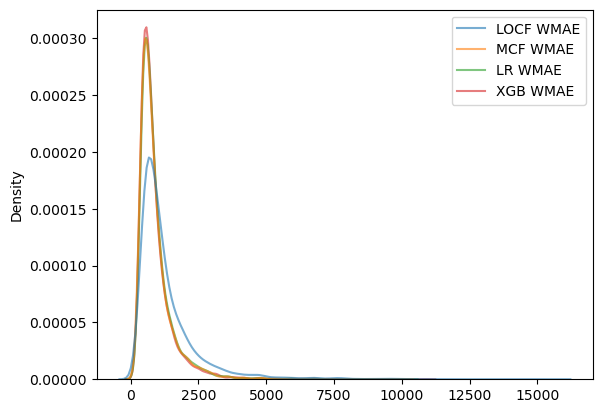

In [125]:
sns.kdeplot(intra_wmae_compare_df, alpha=0.6);

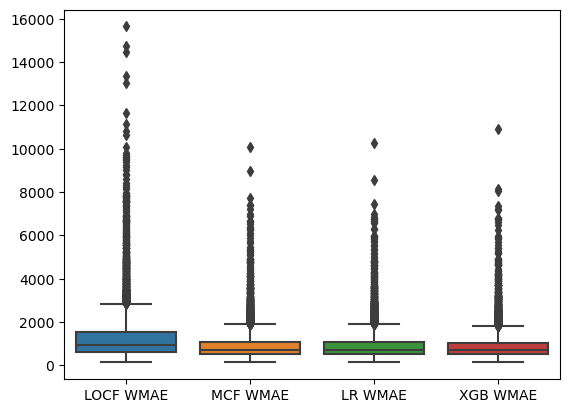

In [126]:
sns.boxplot(intra_wmae_compare_df);

In [127]:
intra_wmae_compare_df.mean().to_frame().rename(columns={0: "Mean WMAE"})

,Mean WMAE
LOCF WMAE,1298.838018
MCF WMAE,913.361220
LR WMAE,927.417463
XGB WMAE,901.405123


The best performing model is XGBoost with lowest mean WMAE, followed by MCF and linear regression.

## Interday Forecast Evaluation 

In [128]:
inter_locf_resid_df, inter_locf_wmae = evaluate(y_test_inter, y_test_pred_inter_locf, test_weights, "interday")
inter_mcf_resid_df, inter_mcf_wmae = evaluate(y_test_inter, y_test_pred_inter_mcf, test_weights, "interday")
inter_lin_reg_resid_df, inter_lin_reg_wmae = evaluate(y_test_inter, y_test_pred_inter_lin, test_weights, "interday")
inter_xgb_resid_df, inter_xgb_wmae = evaluate(y_test_inter, y_test_pred_inter_xgb, test_weights, "interday")

In [129]:
inter_wmae_compare_df = pd.DataFrame()
inter_wmae_compare_df["LOCF WMAE"] = inter_locf_wmae
inter_wmae_compare_df["MCF WMAE"] = inter_mcf_wmae
inter_wmae_compare_df["LR WMAE"] = inter_lin_reg_wmae
inter_wmae_compare_df["XGB WMAE"] = inter_xgb_wmae

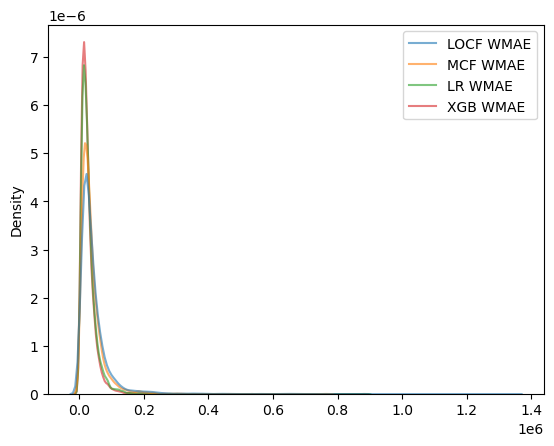

In [130]:
sns.kdeplot(inter_wmae_compare_df, alpha=0.6);

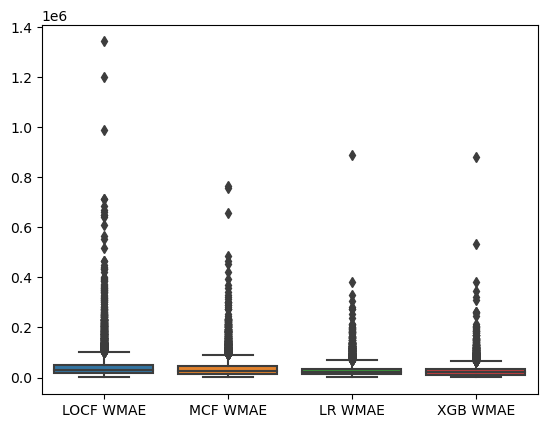

In [131]:
sns.boxplot(inter_wmae_compare_df);

In [132]:
inter_wmae_compare_df.mean().to_frame().rename(columns={0: "Mean WMAE"})

,Mean WMAE
LOCF WMAE,43370.393116
MCF WMAE,37497.093007
LR WMAE,28316.224648
XGB WMAE,26446.975428


For interday returns, the best performing model is still XGBoost. This time, however, the second best is linear regression.

# Error Analysis 🚑

Let's take a look at the residuals of each forecasting target to see if there are any that are poorly forecasted. One assumption is that the further the forecasting target, the more residual it shoud have.

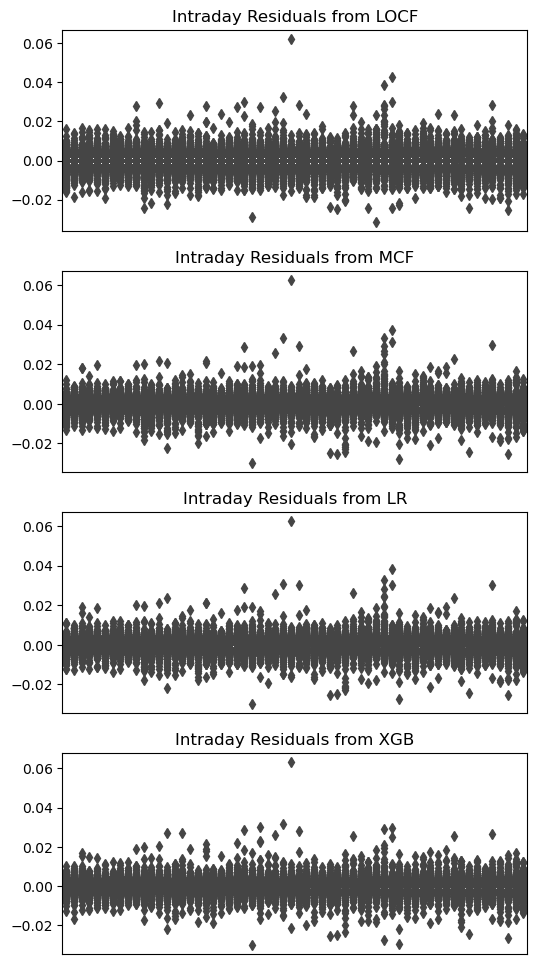

In [133]:
fig, axes = plt.subplots(4, 1, figsize=(6, 4 * 3))
sns.boxplot(intra_locf_resid_df, ax=axes[0])
axes[0].set_title("Intraday Residuals from LOCF")
axes[0].set_xticks([])
sns.boxplot(intra_mcf_resid_df, ax=axes[1])
axes[1].set_title("Intraday Residuals from MCF")
axes[1].set_xticks([])
sns.boxplot(intra_lin_reg_resid_df, ax=axes[2])
axes[2].set_title("Intraday Residuals from LR")
axes[2].set_xticks([])
sns.boxplot(intra_xgb_resid_df, ax=axes[3])
axes[3].set_title("Intraday Residuals from XGB")
axes[3].set_xticks([]);

From the visualization, no clear increment of residuals over time for intraday forecasts.

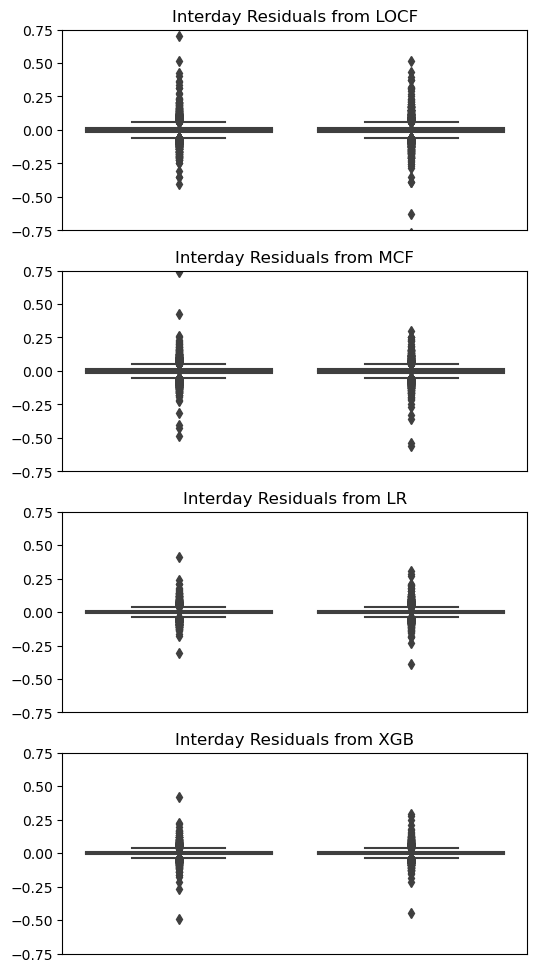

In [134]:
fig, axes = plt.subplots(4, 1, figsize=(6, 4 * 3))
sns.boxplot(inter_locf_resid_df, ax=axes[0])
axes[0].set_title("Interday Residuals from LOCF")
axes[0].set_xticks([])
axes[0].set_ylim(-0.75, 0.75)
sns.boxplot(inter_mcf_resid_df, ax=axes[1])
axes[1].set_title("Interday Residuals from MCF")
axes[1].set_xticks([])
axes[1].set_ylim(-0.75, 0.75)
sns.boxplot(inter_lin_reg_resid_df, ax=axes[2])
axes[2].set_title("Interday Residuals from LR")
axes[2].set_xticks([])
axes[2].set_ylim(-0.75, 0.75)
sns.boxplot(inter_xgb_resid_df, ax=axes[3])
axes[3].set_title("Interday Residuals from XGB")
axes[3].set_xticks([])
axes[3].set_ylim(-0.75, 0.75);

The same goes for interday forecasts.

# Conclusions 💡

The best performing models for the given metrics is XGB. We can use that for our future forecasts. This model might be improved further by performing hyperparameters tuning. Feature engineering of time series have proven to be useful in some instances. Adding rolling mean, rolling standard deviation, and other features might be interesting.

# Further Steps 🎯

- More error analysis (inspect errors on training set, inspect distributions of the errors, inspect points with high residuals, test for autocorrelation)
- Hyperparameters tuning
- Feature importance
- Research more on intraday and interday petterns
- Research more on models that can make intraday forecasts better
- Try other imputation methods
- Try other sets of features (only returns, subsets of lookback returns, last day intraday returns, remove Feature_n that are highly correlated with each other)
- Feature engineering (rolling mean, rolling standard deviation)
- Vectorize the functions

# Thanks to 🙏

- https://www.kaggle.com/code/residentmario/using-missingno-to-diagnose-data-sparsity
- https://stackoverflow.com/a/29008195/13178561
- https://medium.com/@szabo.bibor/how-to-create-a-seaborn-correlation-heatmap-in-python-834c0686b88e